In [15]:
%cd /home/ahmed348/TCNN_repo
EXPERIMENT_NAME = 'HGA_LFC'
NUM_TOP_CHANNELS = 40
FOLD_IDX = 4  
NORMALIZATION = True   
USE_WEIGHTS = True    
feat_path = f'/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder/FEATURES/features_{EXPERIMENT_NAME}'

/home/ahmed348/TCNN_repo


### **imports**

In [30]:
import os, torch
import numpy as np
from torch import nn, optim
from tcnn_utils import get_fold_i, sEEG_EvalDataset
from machine_learning import TemporalCNN_deep
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
from scipy.stats import rankdata
from scipy.stats import wilcoxon, spearmanr, pearsonr
from utils_jgm.tikz_pgf_helpers import tpl_save

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

pts = ['sub-%02d'%i for i in range(1,11)]
print(DEVICE)

def load_channel_labels(txt_path):
    df = pd.read_csv(txt_path, sep="\t")
    labels = df["description"].tolist()
    if EXPERIMENT_NAME == 'HGA_LFC':
        labels = labels + labels  # duplicate in the same order 
    return labels

cuda


#### helper functions

In [31]:
def sign_threshold(x):
    out = np.zeros_like(x)
    out[x > 0] = 1
    out[x < 0] = -1
    return out
def load_label_to_score_map(score_txt_path):
    df = pd.read_csv(score_txt_path, sep="\t", header=None, names=["label", "score"])
    return dict(zip(df["label"], df["score"]))

def compute_channel_importance(model, test_loader, criterion):
    model.eval()
    all_channel_scores = []
    for x, y, _ in test_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        x.requires_grad_(True)
        y_hat = model(x)
        loss = criterion(y_hat, y)
        model.zero_grad()
        loss.backward()
        grads = x.grad.abs()
        T = grads.shape[1]
        channel_scores = grads.mean(dim=1)  # time aggregation
        all_channel_scores.append(channel_scores.detach())
    all_channel_scores = torch.cat(all_channel_scores, dim=0)
    final_channel_importance = all_channel_scores.mean(dim=0)  # (C,)
    if NORMALIZATION:
        final_channel_importance = final_channel_importance / (
            final_channel_importance.sum() + 1e-8
        )
    return final_channel_importance.cpu().numpy()

def compute_channel_importance_not_aggregated(model, test_loader, criterion):
    model.eval()
    all_channel_scores = []
    for x, y, _ in test_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        x.requires_grad_(True)
        y_hat = model(x)
        loss = criterion(y_hat, y)
        model.zero_grad()
        loss.backward()
        grads = x.grad.abs()
        T = grads.shape[1]
        channel_scores = grads.mean(dim=1)  # time aggregation
        all_channel_scores.append(channel_scores.detach())
    all_channel_scores = torch.cat(all_channel_scores, dim=0)
    final_channel_importance = all_channel_scores.mean(dim=0)  # (C,)
    if NORMALIZATION:
        final_channel_importance = final_channel_importance / (
            final_channel_importance.sum() + 1e-8
        )
    return final_channel_importance.cpu().numpy(), all_channel_scores.cpu().numpy()

def compute_channel_importance_l2(model, test_loader, criterion):
    model.eval()
    all_channel_scores = []
    
    for x, y, _ in test_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        x.requires_grad_(True)
        
        y_hat = model(x)
        loss = criterion(y_hat, y)
        
        model.zero_grad()
        loss.backward()
        
        # L2 Norm Implementation
        grads = x.grad  # shape: (B, T, C)
        # Square the gradients, average over time, then take the root
        channel_scores = torch.sqrt(torch.mean(grads**2, dim=1)) # shape: (B, C)
        
        all_channel_scores.append(channel_scores.detach())
        
    all_channel_scores = torch.cat(all_channel_scores, dim=0)
    final_channel_importance = all_channel_scores.mean(dim=0)
    
    if NORMALIZATION:
        final_channel_importance /= (final_channel_importance.sum() + 1e-8)
        
    return final_channel_importance.cpu().numpy()

def select_channels_by_rank(IA, IB, frac=0.25, mode="top"):
    C = len(IA)
    k = int(np.ceil(frac * C))
    rank_A = np.argsort(np.argsort(-IA))  # rank 0 = most important
    rank_B = np.argsort(np.argsort(-IB))
    if mode == "top":
        mask = (rank_A < k) & (rank_B < k)
    elif mode == "bottom":
        mask = (rank_A >= C - k) & (rank_B >= C - k)
    else:
        raise ValueError("mode must be 'top' or 'bottom'")
    return mask

#### more helper functions (newer)

In [32]:
def get_permuted_targets(targets):
    # Assuming the time dimension is dim=1 (common for [B, T, C])
    # If your time dimension is dim=2 (e.g., [B, C, T]), change time_dim accordingly.
    time_dim = 1 
    time_len = targets.size(time_dim)
    # Generate a random permutation of indices for the time axis
    perm_indices = torch.randperm(time_len, device=targets.device)
    # Apply the permutation across the time dimension
    if time_dim == 1:
        permuted_targets = targets[:, perm_indices, :]
    else:
        permuted_targets = targets[:, :, perm_indices]
    return permuted_targets

def do_circular_shift(y, shift=300, dim=1): ## shape : (bs, time_dim, channels)
    return torch.roll(y, shifts=shift, dims=dim)

def compute_saliency(model, loader, criterion, device, permute = False, circular_shift=False, shift=300):
    model.eval()
    all_channel_scores = []
    for x, y, _ in loader:
        x = x.to(device)
        y = y.to(device) 
        x.requires_grad_(True)
        y_hat = model(x)
        if permute:
            y = get_permuted_targets(y)
        if circular_shift:
            y_shifted = do_circular_shift(y=y, shift=shift)
        else:
            y_shifted = y
        # loss = criterion(y_hat, y_shifted)
        # loss = y_hat.abs()
        loss = torch.linalg.norm(y_hat) 
        model.zero_grad()
        loss.backward()
        grads = x.grad.abs()  # (bs, time, channels)
        channel_scores = grads.mean(dim=1)  # aggregate time
        all_channel_scores.append(channel_scores.detach())
    all_channel_scores = torch.cat(all_channel_scores, dim=0)
    final_channel_importance = all_channel_scores.mean(dim=0)  # avg batch
    return final_channel_importance

def permute_model_weights(model):
    """
    Permutes weights within each parameter tensor independently.
    Preserves shape and distribution, but destroys learned structure.
    """
    permuted_model = type(model)(*model.args) if hasattr(model, "args") else None
    # fallback: deepcopy if constructor args not stored
    if permuted_model is None:
        import copy
        permuted_model = copy.deepcopy(model)
    with torch.no_grad():
        for name, param in permuted_model.named_parameters():
            if param.requires_grad:
                flat = param.view(-1)
                perm = torch.randperm(flat.shape[0], device=flat.device)
                shuffled = flat[perm].view_as(param)
                param.copy_(shuffled)
    return permuted_model
import copy
def permute_model_weights_v2(model, global_shuffle=False, shuffle_buffers=False):
    # 1. Use deepcopy as the reliable standard
    permuted_model = copy.deepcopy(model)
    with torch.no_grad():
        if global_shuffle:
            # Flatten all params into one vector, shuffle, and redistribute
            all_params = [p for p in permuted_model.parameters()]
            flat_all = torch.cat([p.view(-1) for p in all_params])
            perm = torch.randperm(flat_all.size(0), device=flat_all.device)
            shuffled_all = flat_all[perm]
            pointer = 0
            for p in all_params:
                numel = p.numel()
                p.copy_(shuffled_all[pointer:pointer + numel].view_as(p))
                pointer += numel
        else:
            # Standard per-layer shuffle (including buffers if requested)
            target_tensors = list(permuted_model.parameters())
            if shuffle_buffers:
                target_tensors += list(permuted_model.buffers())
            for param in target_tensors:
                flat = param.view(-1)
                perm = torch.randperm(flat.shape[0], device=flat.device)
                param.copy_(flat[perm].view_as(param))
    return permuted_model

def get_null_adjusted_saliencies(model, saved_weights_path, test_loader, criterion, percentile=99):
    criterion = nn.MSELoss()
    random_init_model = copy.deepcopy(model)
    model.load_state_dict(torch.load(saved_weights_path))
    model.eval()
    NUM_BASELINE_RUNS = 100
    null_distributions = []
    # print("Computing baseline with permuted weights...")
    for i in range(NUM_BASELINE_RUNS):
        perm_model = permute_model_weights_v2(model)
        perm_model = perm_model.to(DEVICE)
        perm_model.eval()
        saliency = compute_saliency(perm_model, test_loader, criterion, DEVICE, permute=False, circular_shift=False, shift=300)
        null_distributions.append(saliency.cpu().numpy())
    null_distributions = np.stack(null_distributions, axis=0)  # (runs, channels)
    true_saliency = compute_saliency(model, test_loader, criterion, DEVICE)
    true_saliency = true_saliency.cpu().numpy()
    threshold = np.percentile(null_distributions, percentile, axis=0)
    # print(f'threshold : {threshold}')
    filtered_saliency = true_saliency.copy()
    filtered_saliency -= threshold 
    filtered_saliency[filtered_saliency < 0] = 0
    final_channel_importance = filtered_saliency
    if NORMALIZATION:
        final_channel_importance = final_channel_importance / (
            final_channel_importance.sum() + 1e-8
        )
    return final_channel_importance

### **generate the histogram-style importance scores (subjects 1 & 6)**

In [ ]:
k = FOLD_IDX  # arbitrary fold number
topk_labels_all = []
topk_importance_all = []   # <-- define once BEFORE the subject loop

# -------------------------------------------------
# Create a single figure with ten subplots
# -------------------------------------------------
sub_list = [0, 5]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
subplot_idx = 0  # keeps track of (a), (b)

## load channel to color information:
def load_label_to_score_map(txt_path):
    label_to_score = {}
    with open(txt_path, "r") as f:
        for line in f:
            name, score = line.strip().split()
            label_to_score[name] = int(score)
    return label_to_score

score_txt_path = "/home/ahmed348/TCNN_repo/channel_speech_scores.txt"
label_to_class = load_label_to_score_map(score_txt_path)

for pNr, pt in enumerate(pts):
    if pNr not in sub_list:
        continue
    print(f'pnr : {pNr}')
    spectrogram = np.load(os.path.join(feat_path, f'{pt}_spec.npy'))
    eeg = np.load(os.path.join(feat_path, f'{pt}_feat.npy'))
    va_labels = np.load(os.path.join(feat_path, f'{pt}_va.npy'))

    print(f'patient number : {pNr+1}, fold number : {k}') 
    X_train, y_train, va_labels_train, X_test, y_test, \
        va_labels_test = get_fold_i(eeg, spectrogram, va_labels, 10, k)

    channel_means_train = np.mean(X_train, axis=0)
    channel_stds_train = np.std(X_train, axis=0)
    channel_means_test = np.mean(X_test, axis=0)
    channel_stds_test = np.std(X_test, axis=0)

    X_train = (X_train - channel_means_train) / channel_stds_train
    X_test = (X_test - channel_means_test) / channel_stds_test

    X_train = torch.from_numpy(X_train)
    y_train = torch.from_numpy(y_train)
    X_test = torch.from_numpy(X_test)
    y_test = torch.from_numpy(y_test)

    test_dataset = sEEG_EvalDataset(X_test, y_test, va_labels_test, 6)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    input_channels = X_train.shape[-1]
    output_dim = 80

    model = TemporalCNN_deep(
        input_channels, output_dim, [15, 15, 15], [1, 3, 5], 128, 0
    ).to(DEVICE)

    criterion = nn.MSELoss()
    saved_weights_path = f'/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder/SAVED_WEIGHTS/weights_{EXPERIMENT_NAME}_135_dil_151515_ker_7500_T_6/weights_{pt}_fold_{k}.pth'

    final_channel_importance = get_null_adjusted_saliencies(model, saved_weights_path, test_loader, criterion, percentile=99)

    txt_path = f"/scratch/gilbreth/ahmed348/public_datasets/Dutch_Dataset/sub-{pNr+1:02}/ieeg/sub-{pNr+1:02}_task-wordProduction_channels.tsv"
    channel_labels = load_channel_labels(txt_path)

    channel_importance = final_channel_importance #.cpu().numpy()
    sorted_indices = np.argsort(-channel_importance)

    ##
    sorted_labels = [channel_labels[i] for i in sorted_indices]
    sorted_importance = channel_importance[sorted_indices]

    # -------------------------------------------------
    # Remove "unknown" class (case insensitive)
    # -------------------------------------------------
    filtered_labels = []
    filtered_importance = []

    for lbl, imp in zip(sorted_labels, sorted_importance):
        # print(lbl)
        # class_value = label_to_class.get(lbl, 0)
        # if your txt file contains strings like "Unknown"
        if isinstance(lbl, str):
            if lbl.lower() == "unknown":
                continue
        filtered_labels.append(lbl)
        filtered_importance.append(imp)

    filtered_importance = np.array(filtered_importance)

    # -------------------------------------------------
    # Now compute top-K from remaining electrodes
    # -------------------------------------------------
    K = NUM_TOP_CHANNELS

    sorted_importance_norm = filtered_importance / filtered_importance.sum()
    topk_importance = sorted_importance_norm[:K]
    topk_labels = filtered_labels[:K]


    #### map label class to colors
    class_to_color = {
        1: "red",
        -1: "blue",
        0: "white"
    }

    topk_classes = [label_to_class.get(lbl, 0) for lbl in topk_labels]
    bar_colors = [class_to_color[c] for c in topk_classes]
    #### 

    topk_labels_all.append(topk_labels)
    topk_importance_all.append(topk_importance)

    # -------------------------------------------------
    # Plot into subplot
    # -------------------------------------------------
    ax = axes[subplot_idx]
    # ax.bar(np.arange(K), topk_importance)
    ax.bar(
    np.arange(K),
    topk_importance,
    color=bar_colors,
    edgecolor="black"  # keeps white bars visible
    )
    ###
    ax.set_xticks(np.arange(K))
    ax.set_xticklabels(topk_labels, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("$I_c$ (normalized)")
    ax.set_title(f"part-{pNr+1:02}")
    ax.set_title(f"P{pNr+1}")

    ax.text(
    -0.12, 1.08,
    f"({chr(97 + subplot_idx)})",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top"
    )
    subplot_idx += 1

# add the legend
legend_elements = [
    Patch(facecolor="red", edgecolor="black", label="Sensorimotor"),
    Patch(facecolor="blue", edgecolor="black", label="Auditory"),
    Patch(facecolor="white", edgecolor="black", label="Other")
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=4,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, 0.95)
)
# -------------------------------------------------
# Final layout & save
# -------------------------------------------------
# plt.tight_layout() # without legend
plt.tight_layout(rect=[0, 0, 1, 0.9])  # with legend, for just sub 1 & 6
plt.savefig(
    f"/home/ahmed348/TCNN_repo/figures/channel_importance_{EXPERIMENT_NAME.lower()}_sub_1_6.pdf",
    bbox_inches="tight"
)
# tpl_save(
#     figure=fig,
#     filepath=f"/home/ahmed348/TCNN_repo/tex_files/channel_importance_{EXPERIMENT_NAME.lower()}_sub_1_6.tex"
# )
plt.show()

### **generate the histogram-style importance scores (separate subjects) -- for matplotlib2tikz**

In [ ]:
k = FOLD_IDX  # arbitrary fold number
topk_labels_all = []
topk_importance_all = []   # <-- define once BEFORE the subject loop

# -------------------------------------------------
# Create a single figure with ten subplots
# -------------------------------------------------
fig, ax = plt.subplots()
sub_list = [0]

## load channel to color information:
def load_label_to_score_map(txt_path):
    label_to_score = {}
    with open(txt_path, "r") as f:
        for line in f:
            name, score = line.strip().split()
            label_to_score[name] = int(score)
    return label_to_score

score_txt_path = "/home/ahmed348/TCNN_repo/channel_speech_scores.txt"
label_to_class = load_label_to_score_map(score_txt_path)

for pNr, pt in enumerate(pts):
    if pNr not in sub_list:
        continue
    print(f'pnr : {pNr}')
    spectrogram = np.load(os.path.join(feat_path, f'{pt}_spec.npy'))
    eeg = np.load(os.path.join(feat_path, f'{pt}_feat.npy'))
    va_labels = np.load(os.path.join(feat_path, f'{pt}_va.npy'))

    print(f'patient number : {pNr+1}, fold number : {k}') 
    X_train, y_train, va_labels_train, X_test, y_test, \
        va_labels_test = get_fold_i(eeg, spectrogram, va_labels, 10, k)

    channel_means_train = np.mean(X_train, axis=0)
    channel_stds_train = np.std(X_train, axis=0)
    channel_means_test = np.mean(X_test, axis=0)
    channel_stds_test = np.std(X_test, axis=0)

    X_train = (X_train - channel_means_train) / channel_stds_train
    X_test = (X_test - channel_means_test) / channel_stds_test

    X_train = torch.from_numpy(X_train)
    y_train = torch.from_numpy(y_train)
    X_test = torch.from_numpy(X_test)
    y_test = torch.from_numpy(y_test)

    test_dataset = sEEG_EvalDataset(X_test, y_test, va_labels_test, 6)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    input_channels = X_train.shape[-1]
    output_dim = 80

    model = TemporalCNN_deep(
        input_channels, output_dim, [15, 15, 15], [1, 3, 5], 128, 0
    ).to(DEVICE)

    criterion = nn.MSELoss()
    saved_weights_path = f'/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder' \
        f'/SAVED_WEIGHTS/weights_{EXPERIMENT_NAME}_135_dil_151515_ker_7500_T_6/weights_{pt}_fold_{k}.pth'

    final_channel_importance = get_null_adjusted_saliencies(model, saved_weights_path, test_loader, criterion, percentile=99)

    txt_path = f"/scratch/gilbreth/ahmed348/public_datasets/Dutch_Dataset" \
        f"/sub-{pNr+1:02}/ieeg/sub-{pNr+1:02}_task-wordProduction_channels.tsv"
    channel_labels = load_channel_labels(txt_path)

    channel_importance = final_channel_importance #.cpu().numpy()
    sorted_indices = np.argsort(-channel_importance)
    ##
    sorted_labels = [channel_labels[i] for i in sorted_indices]
    sorted_importance = channel_importance[sorted_indices]

    ## Remove "unknown" class (case insensitive)
    filtered_labels = []
    filtered_importance = []

    for lbl, imp in zip(sorted_labels, sorted_importance):
        # if your txt file contains strings like "Unknown"
        if isinstance(lbl, str):
            if lbl.lower() == "unknown":
                continue
        filtered_labels.append(lbl)
        filtered_importance.append(imp)

    filtered_importance = np.array(filtered_importance)

    ## Now compute top-K from remaining electrodes
    K = NUM_TOP_CHANNELS
    #### sorted_importance_norm = filtered_importance / filtered_importance.sum()
    sorted_importance_norm = filtered_importance ## don't normalize again after removing 'unknowns'
    topk_importance = sorted_importance_norm[:K]
    topk_labels = filtered_labels[:K]

    #### map label class to colors
    class_to_color = {
        1: "red",
        -1: "blue",
        0: "white"
    }
    topk_classes = [label_to_class.get(lbl, 0) for lbl in topk_labels]
    bar_colors = [class_to_color[c] for c in topk_classes]
    #### 
    topk_labels_all.append(topk_labels)
    topk_importance_all.append(topk_importance)
    ## Plot into subplot
    # ax.bar(np.arange(K), topk_importance)
    ax.bar(
    np.arange(K),
    topk_importance,
    color=bar_colors,
    edgecolor="black"  # keeps white bars visible
    )
    ###
    ax.set_xticks(np.arange(K))
    ax.set_xticklabels(topk_labels, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("channel importance")
    ax.set_title(f"P{pNr+1}")

# add the legend
legend_elements = [
    Patch(facecolor="red", edgecolor="black", label="Speech Motor"),
    Patch(facecolor="blue", edgecolor="black", label="Perceptual"),
    Patch(facecolor="white", edgecolor="black", label="Other")
]
fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=4,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, 0.95)
)
# -------------------------------------------------
# Final layout & save
# -------------------------------------------------
# plt.tight_layout() # without legend
plt.tight_layout(rect=[0, 0, 1, 0.9])  # with legend, for just sub 1 & 6
# plt.savefig(
#     f"/home/ahmed348/TCNN_repo/figures/channel_importance_{EXPERIMENT_NAME.lower()}_sub_{sub_list[0]}.pdf",
#     bbox_inches="tight"
# )
tpl_save(
    figure=fig,
    filepath=f"/home/ahmed348/TCNN_repo/tex_files/channel_importance_{EXPERIMENT_NAME.lower()}_sub_{sub_list[0]+1}_top25.tex",
    extra_axis_parameters = {r'xticklabel style={rotate=45.0,anchor=east,font=\tiny}'}
)
plt.show()

### generate saliency plots across time

In [ ]:
k = FOLD_IDX  # arbitrary fold number
topk_labels_all = []
topk_importance_all = []   # <-- define once BEFORE the subject loop

# -------------------------------------------------
# Create a single figure with ten subplots
# -------------------------------------------------
fig, ax = plt.subplots()
sub_list = [0]

## load channel to color information:
def load_label_to_score_map(txt_path):
    label_to_score = {}
    with open(txt_path, "r") as f:
        for line in f:
            name, score = line.strip().split()
            label_to_score[name] = int(score)
    return label_to_score

score_txt_path = "/home/ahmed348/TCNN_repo/channel_speech_scores.txt"
label_to_class = load_label_to_score_map(score_txt_path)

for pNr, pt in enumerate(pts):
    if pNr not in sub_list:
        continue
    print(f'pnr : {pNr}')
    spectrogram = np.load(os.path.join(feat_path, f'{pt}_spec.npy'))
    eeg = np.load(os.path.join(feat_path, f'{pt}_feat.npy'))
    va_labels = np.load(os.path.join(feat_path, f'{pt}_va.npy'))

    print(f'patient number : {pNr+1}, fold number : {k}') 
    X_train, y_train, va_labels_train, X_test, y_test, \
        va_labels_test = get_fold_i(eeg, spectrogram, va_labels, 10, k)

    channel_means_train = np.mean(X_train, axis=0)
    channel_stds_train = np.std(X_train, axis=0)
    channel_means_test = np.mean(X_test, axis=0)
    channel_stds_test = np.std(X_test, axis=0)

    X_train = (X_train - channel_means_train) / channel_stds_train
    X_test = (X_test - channel_means_test) / channel_stds_test

    X_train = torch.from_numpy(X_train)
    y_train = torch.from_numpy(y_train)
    X_test = torch.from_numpy(X_test)
    y_test = torch.from_numpy(y_test)

    test_dataset = sEEG_EvalDataset(X_test, y_test, va_labels_test, 6)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    input_channels = X_train.shape[-1]
    output_dim = 80

    model = TemporalCNN_deep(
        input_channels, output_dim, [15, 15, 15], [1, 3, 5], 128, 0
    ).to(DEVICE)

    criterion = nn.MSELoss()
    saved_weights_path = f'/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder' \
        f'/SAVED_WEIGHTS/weights_{EXPERIMENT_NAME}_135_dil_151515_ker_7500_T_6/weights_{pt}_fold_{k}.pth'

    model.load_state_dict(torch.load(saved_weights_path))
    model.eval()

    all_channel_scores = []
    all_channel_scores_vs_time = []

    for x, y, _ in test_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        x.requires_grad_(True)

        y_hat = model(x)
        loss = criterion(y_hat, y)

        model.zero_grad()
        loss.backward()

        grads = x.grad.abs()
        grads_raw = x.grad 
        print(f'grad shape : {grads.shape}')
        channel_scores = grads.mean(dim=1) ## aggregate the time dimension
        all_channel_scores.append(channel_scores.detach())
        all_channel_scores_vs_time.append(grads_raw.detach()) 

    all_channel_scores = torch.cat(all_channel_scores, dim=0)
    final_channel_importance = all_channel_scores.mean(dim=0) ## aggregate across batches
    # final_channel_importance -= final_channel_importance.min() ## subtract the mean
    # if NORMALIZATION:
    #     final_channel_importance = final_channel_importance / (
    #         final_channel_importance.sum() + 1e-8
    #     )

    final_all_channel_scores_vs_time = torch.cat(all_channel_scores_vs_time, dim=0)
    final_all_channel_scores_vs_time = final_all_channel_scores_vs_time.mean(dim=0).cpu().numpy()
    print(f'non-aggregated saliencies : {final_all_channel_scores_vs_time.shape}')


    txt_path = f"/scratch/gilbreth/ahmed348/public_datasets/Dutch_Dataset" \
        f"/sub-{pNr+1:02}/ieeg/sub-{pNr+1:02}_task-wordProduction_channels.tsv"
    channel_labels = load_channel_labels(txt_path)

    channel_importance = final_channel_importance.cpu().numpy()
    print(f'channel importance shape : {channel_importance.shape}') 
    sorted_indices = np.argsort(-channel_importance)
    ##
    sorted_labels = [channel_labels[i] for i in sorted_indices]
    sorted_importance = channel_importance[sorted_indices]

    ## Remove "unknown" class (case insensitive)
    filtered_labels = []
    filtered_importance = []

    for lbl, imp in zip(sorted_labels, sorted_importance):
        # if your txt file contains strings like "Unknown"
        if isinstance(lbl, str):
            if lbl.lower() == "unknown":
                continue
        filtered_labels.append(lbl)
        filtered_importance.append(imp)

    filtered_importance = np.array(filtered_importance)

    ## Now compute top-K from remaining electrodes
    K = NUM_TOP_CHANNELS
    #### sorted_importance_norm = filtered_importance / filtered_importance.sum()
    sorted_importance_norm = filtered_importance ## don't normalize again after removing 'unknowns'
    topk_importance = sorted_importance_norm[:K]
    topk_labels = filtered_labels[:K]

    #### map label class to colors
    class_to_color = {
        1: "red",
        -1: "blue",
        0: "white"
    }

    topk_classes = [label_to_class.get(lbl, 0) for lbl in topk_labels]
    bar_colors = [class_to_color[c] for c in topk_classes]
    #### 

    topk_labels_all.append(topk_labels)
    topk_importance_all.append(topk_importance)

print(sorted_indices)
idx = 0
print(sorted_importance[idx])
plt.figure(figsize=(10, 6))
plt.subplot(121); plt.plot(final_all_channel_scores_vs_time[:, sorted_indices[0]]); plt.title(f'sorted channel idx : {0}')
plt.subplot(122); plt.plot(final_all_channel_scores_vs_time[:, sorted_indices[-1]]); plt.title(f'sorted channel idx : {-1}')

### **generate null saliencies alongside true saliencies**

#### test the null saliencies on random subjects

In [ ]:
from scipy import stats

k = FOLD_IDX  # arbitrary fold number
topk_labels_all = []; topk_importance_all = []   # <-- define once BEFORE the subject loop
fig, ax = plt.subplots()
## load channel to color information:
def load_label_to_score_map(txt_path):
    label_to_score = {}
    with open(txt_path, "r") as f:
        for line in f:
            name, score = line.strip().split()
            label_to_score[name] = int(score) 
    return label_to_score
score_txt_path = "/home/ahmed348/TCNN_repo/channel_speech_scores.txt"
label_to_class = load_label_to_score_map(score_txt_path)
sub_list = [2]
for pNr, pt in enumerate(pts):
    if pNr not in sub_list:
        continue
    print(f'pnr : {pNr}')
    spectrogram = np.load(os.path.join(feat_path, f'{pt}_spec.npy'))
    eeg = np.load(os.path.join(feat_path, f'{pt}_feat.npy'))
    va_labels = np.load(os.path.join(feat_path, f'{pt}_va.npy'))
    print(f'patient number : {pNr+1}, fold number : {k}') 
    X_train, y_train, va_labels_train, X_test, y_test, \
        va_labels_test = get_fold_i(eeg, spectrogram, va_labels, 10, k)
    channel_means_train = np.mean(X_train, axis=0)
    channel_stds_train = np.std(X_train, axis=0)
    channel_means_test = np.mean(X_test, axis=0)
    channel_stds_test = np.std(X_test, axis=0)
    X_train = (X_train - channel_means_train) / channel_stds_train
    X_test = (X_test - channel_means_test) / channel_stds_test
    X_train = torch.from_numpy(X_train); y_train = torch.from_numpy(y_train)
    X_test = torch.from_numpy(X_test); y_test = torch.from_numpy(y_test)
    test_dataset = sEEG_EvalDataset(X_test, y_test, va_labels_test, 6) 
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
    input_channels = X_train.shape[-1]
    output_dim = 80 
    model = TemporalCNN_deep(
        input_channels, output_dim, [15, 15, 15], [1, 3, 5], 128, 0
    ).to(DEVICE)
    model_random_init = TemporalCNN_deep(
        input_channels, output_dim, [15, 15, 15], [1, 3, 5], 128, 0
    ).to(DEVICE) 
    criterion = nn.MSELoss()
    saved_weights_path = f'/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder' \
        f'/SAVED_WEIGHTS/weights_{EXPERIMENT_NAME}_135_dil_151515_ker_7500_T_6/weights_{pt}_fold_{k}.pth'
    model.load_state_dict(torch.load(saved_weights_path)); 
    model.eval() 
    NUM_BASELINE_RUNS = 100
    null_distributions = []
    print("Computing baseline with permuted weights...") 
    for i in range(NUM_BASELINE_RUNS): 
        perm_model = permute_model_weights_v2(model)
        perm_model = perm_model.to(DEVICE)
        perm_model.eval()
        saliency = compute_saliency(perm_model, test_loader, criterion, DEVICE, permute=False, circular_shift=False, shift=300)
        null_distributions.append(saliency.cpu().numpy())

    null_distributions = np.stack(null_distributions, axis=0)  # (runs, channels)
    true_saliency = compute_saliency(model, test_loader, criterion, DEVICE)
    true_saliency = true_saliency.cpu().numpy()

    print(f'null saliencies shape : {null_distributions.shape}')
    print(f'true saliency shape : {true_saliency.shape}')
    avg_null_saliencies = np.average(null_distributions, axis=0, keepdims=False)

    correlation_coefficient, p_value = stats.pearsonr(avg_null_saliencies.flatten(), true_saliency.flatten())
    print(f"Pearson Correlation Coefficient (r): {correlation_coefficient}")
    print(f"P-value: {p_value}")

    # threshold = np.percentile(null_distributions.flatten(), 95) #, axis=0) 
    threshold = np.percentile(null_distributions, 99, axis=0)
    print(f'threshold : {threshold}')
    true_saliency = true_saliency - threshold
    filtered_saliency = true_saliency.copy()
    filtered_saliency[filtered_saliency < 0] = 0
    print(f'filtered_saliency : {filtered_saliency}')

    final_channel_importance = filtered_saliency
    # if NORMALIZATION:
    #     final_channel_importance = final_channel_importance / (
    #         final_channel_importance.sum() + 1e-8
    #     )

    txt_path = f"/scratch/gilbreth/ahmed348/public_datasets/Dutch_Dataset" \
        f"/sub-{pNr+1:02}/ieeg/sub-{pNr+1:02}_task-wordProduction_channels.tsv"
    channel_labels = load_channel_labels(txt_path)

    channel_importance = final_channel_importance #$.cpu().numpy()
    sorted_indices = np.argsort(-channel_importance)
    ##
    sorted_labels = [channel_labels[i] for i in sorted_indices]
    sorted_importance = channel_importance[sorted_indices]

    ## Remove "unknown" class (case insensitive)
    filtered_labels = []
    filtered_importance = []

    for lbl, imp in zip(sorted_labels, sorted_importance):
        # if your txt file contains strings like "Unknown"
        if isinstance(lbl, str):
            if lbl.lower() == "unknown":
                continue
        filtered_labels.append(lbl)
        filtered_importance.append(imp)
    filtered_importance = np.array(filtered_importance)

    ## Now compute top-K from remaining electrodes
    K = NUM_TOP_CHANNELS
    #### sorted_importance_norm = filtered_importance / filtered_importance.sum()
    sorted_importance_norm = filtered_importance ## don't normalize again after removing 'unknowns'
    topk_importance = sorted_importance_norm[:K]
    topk_labels = filtered_labels[:K]

    #### map label class to colors
    class_to_color = {
        1: "red",
        -1: "blue",
        0: "white"
    }
    topk_classes = [label_to_class.get(lbl, 0) for lbl in topk_labels]
    bar_colors = [class_to_color[c] for c in topk_classes]
    #### 
    topk_labels_all.append(topk_labels)
    topk_importance_all.append(topk_importance)
    ## Plot into subplot
    # ax.bar(np.arange(K), topk_importance)
    ax.bar(
    np.arange(K),
    topk_importance,
    color=bar_colors,
    edgecolor="black"  # keeps white bars visible
    )
    ax.set_xticks(np.arange(K))
    ax.set_xticklabels(topk_labels, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("channel importance")
    ax.set_title(f"P{pNr+1}")
# add the legend
legend_elements = [
    Patch(facecolor="red", edgecolor="black", label="Speech Motor"),
    Patch(facecolor="blue", edgecolor="black", label="Perceptual"),
    Patch(facecolor="white", edgecolor="black", label="Other")
]
fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=4,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, 0.95)
)
## Final layout & save
# plt.tight_layout() # without legend 
plt.tight_layout(rect=[0, 0, 1, 0.9])  # with legend, for just sub 1 & 6 
plt.show()

### **generate the histogram-style importance scores (all subjects, supplementary figure)**

pnr : 0
patient number : 1, fold number : 4
summing for subject ID : 0
pnr : 1
patient number : 2, fold number : 4
summing for subject ID : 1
pnr : 2
patient number : 3, fold number : 4
summing for subject ID : 2
pnr : 3
patient number : 4, fold number : 4
summing for subject ID : 3
pnr : 4
patient number : 5, fold number : 4
summing for subject ID : 4
pnr : 5
patient number : 6, fold number : 4
summing for subject ID : 5
pnr : 6
patient number : 7, fold number : 4
summing for subject ID : 6
pnr : 7
patient number : 8, fold number : 4
summing for subject ID : 7
pnr : 8
patient number : 9, fold number : 4
summing for subject ID : 8
pnr : 9
patient number : 10, fold number : 4
summing for subject ID : 9


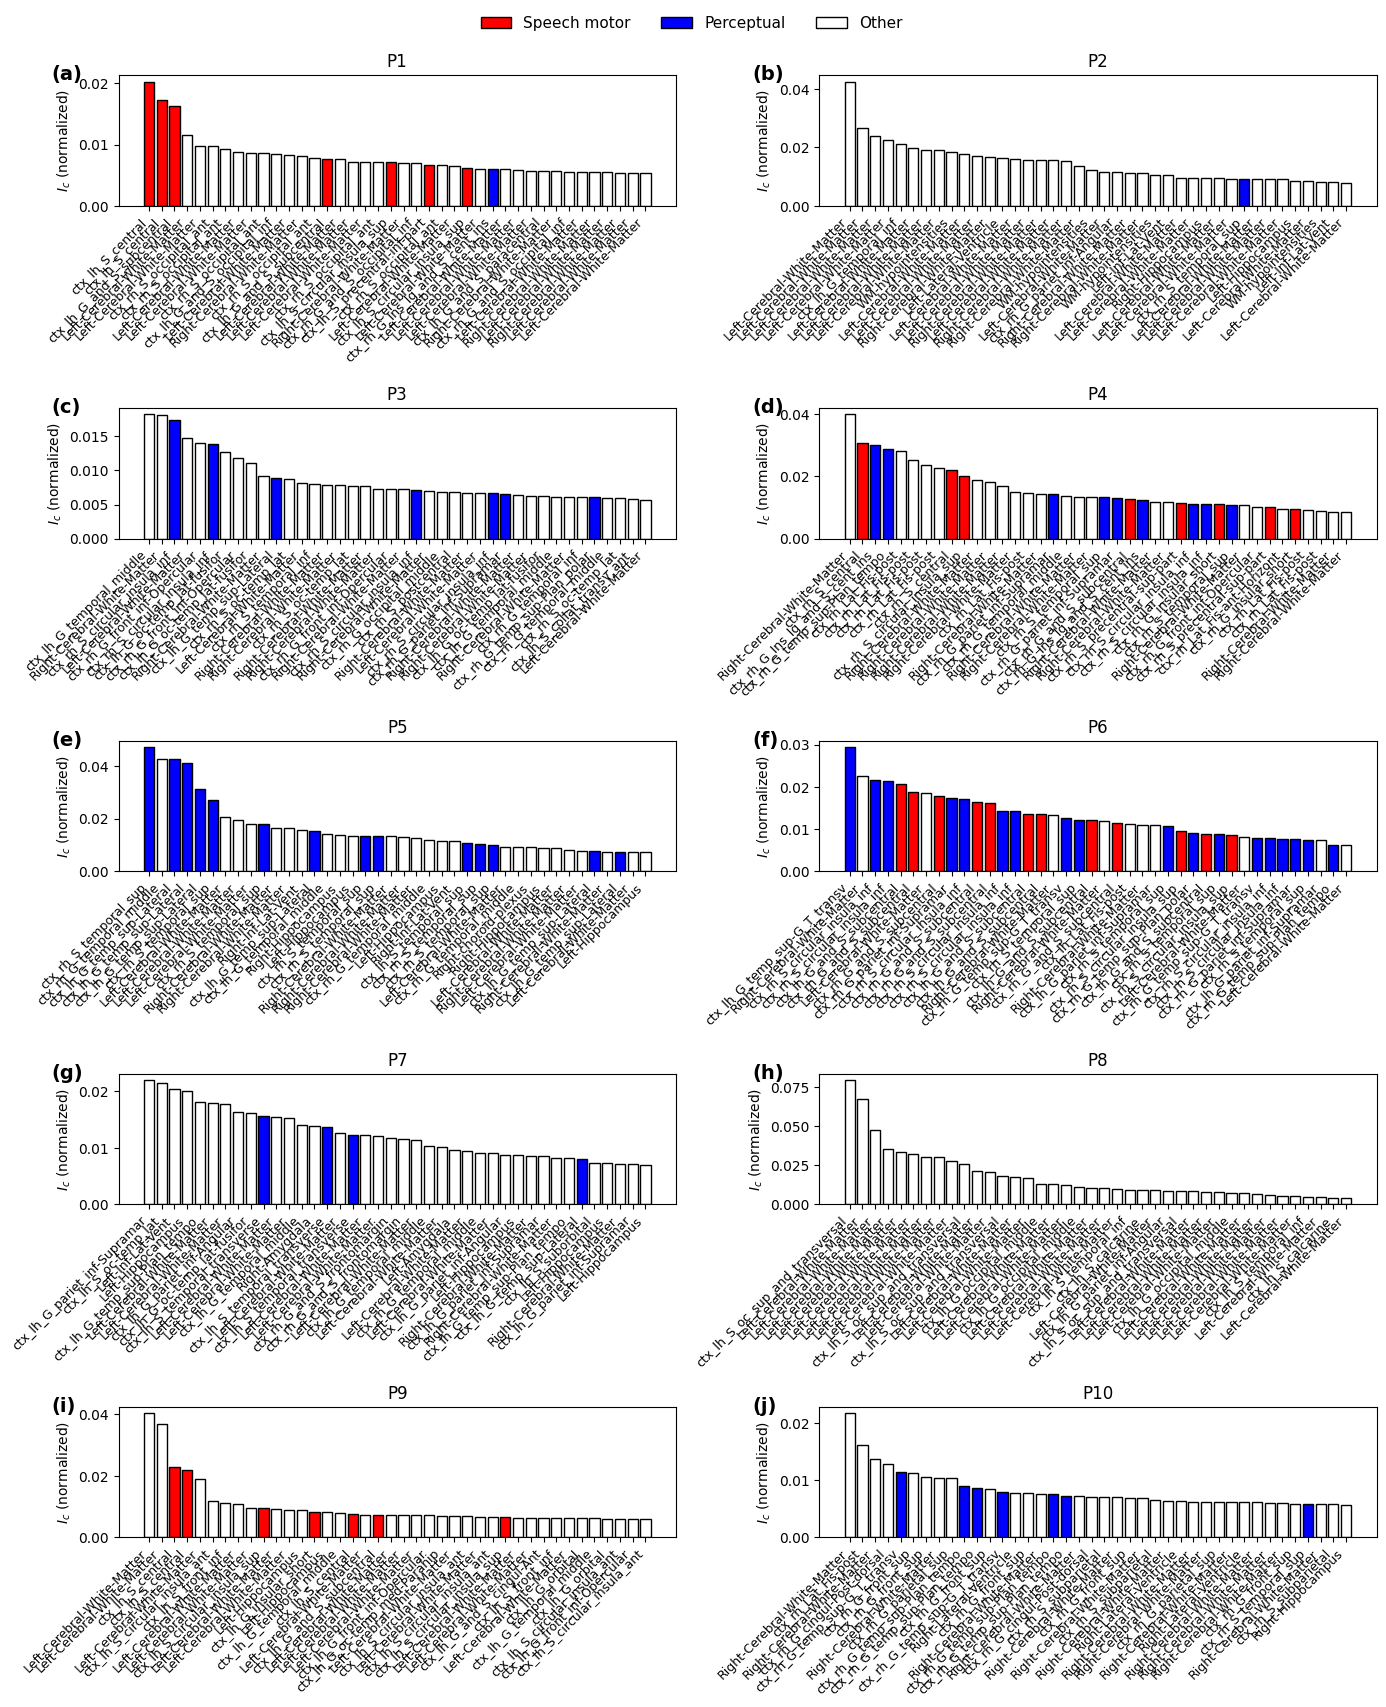

In [6]:
k = FOLD_IDX  # arbitrary fold number
topk_labels_all = []
topk_importance_all = []   # <-- define once BEFORE the subject loop

# -------------------------------------------------
# Create a single figure with ten subplots
# -------------------------------------------------

sub_list = list(range(10))
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()  # easier indexing
subplot_idx = 0

from collections import defaultdict

# Initialize IC as a nested dictionary
IC_causal = defaultdict(dict)
# IC_anticausal = defaultdict(dict)

## load channel to color information:
def load_label_to_score_map(txt_path):
    label_to_score = {}
    with open(txt_path, "r") as f:
        for line in f:
            name, score = line.strip().split()
            label_to_score[name] = int(score)
    return label_to_score

score_txt_path = "/home/ahmed348/TCNN_repo/channel_speech_scores.txt"
label_to_class = load_label_to_score_map(score_txt_path)

for pNr, pt in enumerate(pts):
    if pNr not in sub_list:
        continue
    print(f'pnr : {pNr}')
    spectrogram = np.load(os.path.join(feat_path, f'{pt}_spec.npy'))
    eeg = np.load(os.path.join(feat_path, f'{pt}_feat.npy'))
    va_labels = np.load(os.path.join(feat_path, f'{pt}_va.npy'))

    print(f'patient number : {pNr+1}, fold number : {k}') 
    X_train, y_train, va_labels_train, X_test, y_test, \
        va_labels_test = get_fold_i(eeg, spectrogram, va_labels, 10, k)

    channel_means_train = np.mean(X_train, axis=0)
    channel_stds_train = np.std(X_train, axis=0)
    channel_means_test = np.mean(X_test, axis=0)
    channel_stds_test = np.std(X_test, axis=0)

    X_train = (X_train - channel_means_train) / channel_stds_train
    X_test = (X_test - channel_means_test) / channel_stds_test

    X_train = torch.from_numpy(X_train)
    y_train = torch.from_numpy(y_train)
    X_test = torch.from_numpy(X_test)
    y_test = torch.from_numpy(y_test)

    test_dataset = sEEG_EvalDataset(X_test, y_test, va_labels_test, 6)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    input_channels = X_train.shape[-1]
    output_dim = 80

    model = TemporalCNN_deep(
        input_channels, output_dim, [15, 15, 15], [1, 3, 5], 128, 1
    ).to(DEVICE)

    criterion = nn.MSELoss()
    saved_weights_path = f'/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder/' \
                     f'SAVED_WEIGHTS/weights_{EXPERIMENT_NAME}_135_dil_151515_ker_7500_T_6_causal/weights_{pt}_fold_{k}.pth'
    model.eval()

    final_channel_importance = get_null_adjusted_saliencies(model, saved_weights_path, test_loader, criterion, percentile=99)

    txt_path = f"/scratch/gilbreth/ahmed348/public_datasets/Dutch_Dataset" \
        f"/sub-{pNr+1:02}/ieeg/sub-{pNr+1:02}_task-wordProduction_channels.tsv"
    channel_labels = load_channel_labels(txt_path)

    channel_importance = final_channel_importance #.cpu().numpy()
    sorted_indices = np.argsort(-channel_importance)

    sorted_labels = [channel_labels[i] for i in sorted_indices]
    sorted_importance = channel_importance[sorted_indices]

    # -------------------------------------------------
    # Remove "unknown" class (case insensitive)
    # -------------------------------------------------
    filtered_labels = []
    filtered_importance = []

    for lbl, imp in zip(sorted_labels, sorted_importance):
        # print(lbl)
        # class_value = label_to_class.get(lbl, 0)
        # if your txt file contains strings like "Unknown"
        if isinstance(lbl, str):
            if lbl.lower() == "unknown":
                continue
        filtered_labels.append(lbl)
        filtered_importance.append(imp)

    filtered_importance = np.array(filtered_importance)

    # -------------------------------------------------
    # Now compute top-K from remaining electrodes
    # -------------------------------------------------
    K = NUM_TOP_CHANNELS

    ### sorted_importance_norm = filtered_importance / filtered_importance.sum() ## normalize before removing "unknowns" 
    sorted_importance_norm = filtered_importance
    topk_importance = sorted_importance_norm[:K]
    topk_labels = filtered_labels[:K]

    #### map label class to colors
    class_to_color = {
        1: "red",
        -1: "blue",
        0: "white"
    }
    topk_classes = [label_to_class.get(lbl, 0) for lbl in topk_labels]
    bar_colors = [class_to_color[c] for c in topk_classes]
    #### 

    topk_labels_all.append(topk_labels)
    topk_importance_all.append(topk_importance)

    # -------------------------------------------------
    # Plot into subplot
    # -------------------------------------------------
    ax = axes[subplot_idx]
    # ax.bar(np.arange(K), topk_importance)
    ax.bar(
    np.arange(K),
    topk_importance,
    color=bar_colors,
    edgecolor="black"  # keeps white bars visible
    )
    ###
    ax.set_xticks(np.arange(K))
    ax.set_xticklabels(topk_labels, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("$I_c$ (normalized)")
    ax.set_title(f"P{pNr+1}")

    ax.text(
    -0.12, 1.08,
    f"({chr(97 + subplot_idx)})",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top"
    )
    subplot_idx += 1

    # if pNr in [0, 2, 3, 5]:
    print(f'summing for subject ID : {pNr}')
    tmp_array_red = [topk_importance[i] for i in range(len(topk_classes)) if topk_classes[i]==1]
    tmp_array_blue = [topk_importance[i] for i in range(len(topk_classes)) if topk_classes[i]==-1]
    IC_causal[str(pNr)]['red'] = sum(tmp_array_red)
    IC_causal[str(pNr)]['blue'] = sum(tmp_array_blue)

# add the legend
legend_elements = [
    Patch(facecolor="red", edgecolor="black", label="Speech motor"),
    Patch(facecolor="blue", edgecolor="black", label="Perceptual"),
    Patch(facecolor="white", edgecolor="black", label="Other")
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=4,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, 0.95)
)

## lengend done!
# -------------------------------------------------
# Final layout & save
# -------------------------------------------------
# plt.tight_layout() # without legend
plt.tight_layout(rect=[0, 0, 1, 0.93])  # with legend, for all subjects in one figure
# plt.savefig(
#     f"/home/ahmed348/TCNN_repo/figures/channel_importance_{EXPERIMENT_NAME.lower()}_all_causal.pdf",
#     bbox_inches="tight"
# )
# tpl_save(
#     figure=fig,
#     filepath=f"/home/ahmed348/TCNN_repo/tex_files/channel_importance_{EXPERIMENT_NAME.lower()}_all.tex"
# )
plt.show()

In [7]:
for pNr in range(10):
    print(f'sub : {pNr+1}, CAUSAL model')
    print(f'sum(red)-sum(blue) : {IC_causal[str(pNr)]['red'] - IC_causal[str(pNr)]['blue']}')
    print(f'sub : {pNr+1}, ANTI-CAUSAL model')
    print(f'sum(red)-sum(blue) : {IC_anticausal[str(pNr)]['red']-IC_anticausal[str(pNr)]['blue']}')

sub : 1, CAUSAL model
sum(red)-sum(blue) : 0.07536103529855609
sub : 1, ANTI-CAUSAL model
sum(red)-sum(blue) : 0.0372861223295331
sub : 2, CAUSAL model
sum(red)-sum(blue) : -0.009318809024989605
sub : 2, ANTI-CAUSAL model
sum(red)-sum(blue) : 0
sub : 3, CAUSAL model
sum(red)-sum(blue) : -0.066588478628546
sub : 3, ANTI-CAUSAL model
sum(red)-sum(blue) : -0.0923976469784975
sub : 4, CAUSAL model
sum(red)-sum(blue) : -0.017114633694291115
sub : 4, ANTI-CAUSAL model
sum(red)-sum(blue) : -0.13269533216953278
sub : 5, CAUSAL model
sum(red)-sum(blue) : -0.29528201976791024
sub : 5, ANTI-CAUSAL model
sum(red)-sum(blue) : -0.16521800495684147
sub : 6, CAUSAL model
sum(red)-sum(blue) : -0.06646022805944085
sub : 6, ANTI-CAUSAL model
sum(red)-sum(blue) : -0.15102889435365796
sub : 7, CAUSAL model
sum(red)-sum(blue) : -0.049671826884150505
sub : 7, ANTI-CAUSAL model
sum(red)-sum(blue) : -0.06455222982913256
sub : 8, CAUSAL model
sum(red)-sum(blue) : 0
sub : 8, ANTI-CAUSAL model
sum(red)-sum(blue) 

### draw a scatterplot (**no longer interested, didn't work**)

#### Collect the sensory-motor scores for top k=15 channels (unweighted)

In [ ]:
# import numpy as np
# import pandas as pd

# # Load channel score mapping from the .txt file
# score_df = pd.read_csv("/home/ahmed348/TCNN_repo/channel_speech_scores.txt", sep="\t", header=None, names=["channel", "score"])
# score_dict = dict(zip(score_df["channel"], score_df["score"]))

# # K = 15  # top-k channels to sum
# subject_scores = []  # will hold the sum for each subject

# for pNr, pt in enumerate(sub_list):
#     # ------------------------------
#     # topk_labels is already obtained in your existing loop 
#     # ------------------------------
#     # Map topk labels to scores
#     top_labels_pNr = topk_labels_all[pNr]
#     # print(top_labels_pNr)
#     topk_scores = [score_dict.get(ch, 0) for ch in top_labels_pNr[:K]]  # default 0 if missing
#     # Sum scores to get single score per subject
#     subject_score = sum(topk_scores)
#     subject_scores.append(subject_score)

# subject_scores = np.array(subject_scores)
# print("Top-k summed scores for all subjects:", subject_scores)


#### Do the Channel importance weighted version

In [ ]:
# import numpy as np
# import pandas as pd

# # Load channel speech scores
# score_df = pd.read_csv(
#     "/home/ahmed348/TCNN_repo/channel_speech_scores.txt",
#     sep="\t",
#     header=None,
#     names=["channel", "score"]
# )
# score_dict = dict(zip(score_df["channel"], score_df["score"]))

# subject_scores = []

# for pNr, pt in enumerate(sub_list):

#     # Get labels and importance for this subject
#     top_labels_pNr = topk_labels_all[pNr]
#     top_importance_pNr = topk_importance_all[pNr]   # shape: (K,)

#     # Get speech scores for those channels
#     topk_scores = np.array(
#         [score_dict.get(ch, 0.0) for ch in top_labels_pNr]
#     )

#     # 🔥 WEIGHTED ALGEBRAIC SUM
#     subject_score = np.sum(top_importance_pNr * topk_scores)

#     subject_scores.append(subject_score)

# subject_scores = np.array(subject_scores)
# print("Top-k weighted speech scores for all subjects:", subject_scores)


#### Do it weighted and incorporate uncertainty for 'unknown' channels (Evan's idea)

In [ ]:
import numpy as np
import pandas as pd

# Load channel score mapping
score_df = pd.read_csv(
    "/home/ahmed348/TCNN_repo/channel_speech_scores.txt",
    sep="\t",
    header=None,
    names=["channel", "score"]
)

score_dict = dict(zip(score_df["channel"], score_df["score"]))

K = NUM_TOP_CHANNELS
subject_score_ranges = []  # [(min, max) per subject]

for pNr, pt in enumerate(sub_list):

    top_labels = topk_labels_all[pNr][:K]
    top_imps   = topk_importance_all[pNr][:K]

    score_min = 0.0
    score_max = 0.0

    for ch, imp in zip(top_labels, top_imps):

        # --- Explicit uncertainty handling ---
        if ch == "unknown" or ch not in score_dict:
            score_min -= imp
            score_max += imp
            continue

        # --- Deterministic channels ---
        s = float(score_dict[ch])  # -1, 0, +1
        score_min += s * imp
        score_max += s * imp

    subject_score_ranges.append((score_min, score_max))

subject_score_ranges = np.array(subject_score_ranges)

print("Speech score ranges (min, max) for all subjects:")
print(subject_score_ranges)

#### Collect the causal-anti_causal scores from .pkl files

In [ ]:
import pickle
# ------------------------
# Choose metric 
# ------------------------
metric = "STOI"   # change to "STOI" or "PCC" if needed

# ------------------------
# Load result files
# ------------------------
files = {
    "causal": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6_causal.pkl",
    "anti_causal": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6_anti_causal.pkl",
    "non_causal": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6.pkl",
}
method_order =  list(files.keys())
results = {}
for method, fpath in files.items():
    with open(fpath, "rb") as f:
        data = pickle.load(f)
        results[method] = data[metric]  # list of n_subjects, each with 10 folds

# ------------------------
# Prepare boxplot data
# ------------------------
n_subjects = len(next(iter(results.values())))   # should be 10
methods = list(results.keys())
n_methods = len(methods)

positions = []
box_data = []
labels = []

width = 0.18  # spacing between methods
for subj_idx in range(n_subjects):
    for m_idx, method in enumerate(methods):
        subj_data = results[method][subj_idx]  # list of folds for this subject
        box_data.append(subj_data)
        # center around subject index
        positions.append(subj_idx + 1 + (m_idx - (n_methods-1)/2)*width)
        labels.append(f"Subj {subj_idx+1}" if m_idx == n_methods//2 else "")

# Extend ylim for stars
data_list = box_data
all_data = np.concatenate(data_list)
yrange = all_data.max() - all_data.min()
ax.set_ylim(all_data.min() - yrange*0.025, all_data.max() + yrange*0.39)
ax.grid(True) 

differences = []
# Significance stars
pairs = [("causal", "anti_causal")]
m_bonf = len(pairs)

for s_idx in range(n_subjects):
    start_idx = s_idx * n_methods
    subj_positions = [positions[start_idx + m] for m in range(n_methods)]
    subj_data_arrays = [data_list[start_idx + m] for m in range(n_methods)]
    ymax = max(max(arr) for arr in subj_data_arrays)

    for level, (m1, m2) in enumerate(pairs):
        m1_idx = method_order.index(m1)
        m2_idx = method_order.index(m2)
        # a, b = subj_data_arrays[m1_idx], subj_data_arrays[m2_idx]
        a, b = results[m1][s_idx], results[m2][s_idx] # a->causal, b->anti-causal
        diff = np.mean(a) - np.mean(b)
        differences.append(diff)
print(differences)

#### Generate the scatter plot (did not work)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Unpack ranges
score_min = subject_score_ranges[:, 0]
score_max = subject_score_ranges[:, 1]
score_mid = 0.5 * (score_min + score_max)
score_err = score_max - score_mid   # symmetric half-width

assert len(score_mid) == 10
assert len(differences) == 10

plt.figure(figsize=(6.2, 5))

# --- Scatter with horizontal uncertainty bars ---
plt.errorbar(
    score_mid,
    differences,
    xerr=score_err,
    fmt="o",
    markersize=7,
    markeredgecolor="black",
    markeredgewidth=0.8,
    alpha=0.9,
    capsize=4,
    elinewidth=1.2,
    label="Subjects",
    zorder=3
)

# Reference lines
plt.axhline(0, linestyle="--", linewidth=1, alpha=0.6, zorder=1)
plt.axvline(0, linestyle="--", linewidth=1, alpha=0.6, zorder=1)

# Axis labels
plt.xlabel("Top-$k$ Channel Speech Score (uncertainty-aware)", fontsize=12)
plt.ylabel(r"$STOI_{\mathrm{causal}} - STOI_{\mathrm{anticausal}}$", fontsize=12)

# -------------------------------------------------
# Subject annotations
# -------------------------------------------------
label_offsets = {}

for i in range(10):
    dx, dy = label_offsets.get(i, (0.02, 0.002))
    plt.text(
        score_mid[i] + dx,
        differences[i] + dy,
        f"S{i+1}",
        fontsize=9,
        ha="left",
        va="bottom",
        zorder=4
    )

plt.legend(frameon=False, fontsize=10, loc="upper left")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.savefig(
    "/home/ahmed348/TCNN_repo/figures/scatterplot_causality_speech_score_uncertainty.pdf",
    bbox_inches="tight",
    dpi=600
)
plt.show()


### **Connecting individual electrode saliencies with sensory/motor information -- separate analysis per subject (worked, but omit this)**

#### Compare gradient magnitudes of importance scores -- subject-wise

In [ ]:
from scipy.stats import wilcoxon, spearmanr, pearsonr

sub_list = list(range(10))
# sub_list = [0, 2, 3, 5, 6, 8, 9]
# sub_list = [8]
all_pred = []
all_gt = []

for pNr, pt in enumerate(pts):
    # print(f'patient number : {pNr}')
    if pNr not in sub_list:
        continue
    acc_all = []; differences = []
    chance_acc_all = []

    for FOLD_IDX in range(10):
        # if FOLD_IDX>0:
        #     continue 
        spectrogram = np.load(os.path.join(feat_path, f'{pt}_spec.npy'))
        eeg = np.load(os.path.join(feat_path, f'{pt}_feat.npy'))
        va_labels = np.load(os.path.join(feat_path, f'{pt}_va.npy'))
        X_train, y_train, va_labels_train, X_test, y_test, \
            va_labels_test = get_fold_i(eeg, spectrogram, va_labels, 10, FOLD_IDX)
        channel_means_train = np.mean(X_train, axis=0)
        channel_stds_train = np.std(X_train, axis=0)
        channel_means_test = np.mean(X_test, axis=0)
        channel_stds_test = np.std(X_test, axis=0)
        X_train = (X_train - channel_means_train) / channel_stds_train
        X_test = (X_test - channel_means_test) / channel_stds_test

        X_train = torch.from_numpy(X_train)
        y_train = torch.from_numpy(y_train)
        X_test = torch.from_numpy(X_test)
        y_test = torch.from_numpy(y_test)

        test_dataset = sEEG_EvalDataset(X_test, y_test, va_labels_test, 6) # third entry doesn't matter here!
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

        input_channels = X_train.shape[-1]
        output_dim = 80
        model_A = TemporalCNN_deep(
            input_channels, output_dim, [15, 15, 15], [1, 3, 5], 128, 0
        ).to(DEVICE) # causal
        saved_weights_path_A = f'/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder/SAVED_WEIGHTS/weights_{EXPERIMENT_NAME}_135_dil_151515_ker_7500_T_6_causal/weights_{pt}_fold_{FOLD_IDX}.pth'
        model_A.load_state_dict(torch.load(saved_weights_path_A))
        criterion = nn.MSELoss()
        IA = compute_channel_importance(model_A, test_loader, criterion, 1)
        model_B = TemporalCNN_deep(
            input_channels, output_dim, [15, 15, 15], [1, 3, 5], 128, 0
        ).to(DEVICE) # anti-causal
        saved_weights_path_B = f'/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder/SAVED_WEIGHTS/weights_{EXPERIMENT_NAME}_135_dil_151515_ker_7500_T_6_anti_causal/weights_{pt}_fold_{FOLD_IDX}.pth'
        model_B.load_state_dict(torch.load(saved_weights_path_B))
        IB = compute_channel_importance(model_B, test_loader, criterion, -1)
        diff = IA-IB

        # avg_diff = np.mean(np.array(differences), axis=0)
        pred_vec = sign_threshold(diff)
        txt_path = f"/scratch/gilbreth/ahmed348/public_datasets/Dutch_Dataset/sub-{pNr+1:02}/ieeg/sub-{pNr+1:02}_task-wordProduction_channels.tsv"
        channel_labels = load_channel_labels(txt_path)

        score_txt_path = "/home/ahmed348/TCNN_repo/channel_speech_scores.txt"
        label_to_score = load_label_to_score_map(score_txt_path)
        gt_vec = np.array([
        label_to_score.get(lbl, 0)  # default to 0 if label not found
        for lbl in channel_labels
        ])
        assert len(channel_labels) == len(gt_vec) == len(pred_vec)  
        len_gt_vector = len(gt_vec)
        # ---------------------------------
        # Evaluate only on gt ∈ {-1, +1}
        # ---------------------------------
        eval_mask = (gt_vec != 0)
        # Accuracy (exact match, restricted set)
        if np.sum(eval_mask) > 0:
            acc = np.mean(pred_vec[eval_mask] == gt_vec[eval_mask])
            # acc, _ = pearsonr(pred_vec[eval_mask], gt_vec[eval_mask]) ## acc is the pho here
        else:
            acc = np.nan
        acc_all.append(acc)

        wrong_mask = eval_mask & (pred_vec != gt_vec)
        wrong_channel_dict = {
        channel_labels[i]: {
            "IA": float(IA[i]),
            "IB": float(IB[i]),
            "gt": int(gt_vec[i]),
            "pred": int(pred_vec[i]),
        }
        for i in np.where(wrong_mask)[0]
        }
        # print(wrong_channel_dict)
        # ---------------------------------
        # Permutation-based chance (per fold)
        # ---------------------------------
        n_perm = 1000
        perm_acc = np.zeros(n_perm)
        gt_eval = gt_vec[eval_mask]
        pred_eval = pred_vec[eval_mask]
        for i in range(n_perm):
            gt_perm = np.random.permutation(gt_eval)
            perm_acc[i] = np.mean(pred_eval == gt_perm)
            # perm_acc[i], _ = spearmanr(pred_eval, gt_perm)
        chance_acc_fold = perm_acc.mean()
        chance_acc_all.append(chance_acc_fold)
    true_acc_arr = np.array(acc_all)
    chance_acc_arr = np.array(chance_acc_all)
    diffs = true_acc_arr - chance_acc_arr
    # Remove zero differences (Wilcoxon requirement)
    diffs = diffs[diffs != 0]
    if len(diffs) >= 5:  # rule of thumb minimum
        stat, p_wilcoxon = wilcoxon(diffs, alternative="greater")
    else:
        p_wilcoxon = np.nan
    print(
        f"Sub-{pNr+1:02} | "
        f"Speech channels-{np.sum(eval_mask)}/{len_gt_vector} |"
        f"Mean true acc: {true_acc_arr.mean():.3f} | "
        f"Mean chance acc: {chance_acc_arr.mean():.3f} | "
        f"Wilcoxon p = {p_wilcoxon}"
    )

#### do the same analysis based on importance scores, but pool subjects

In [ ]:
from scipy.stats import wilcoxon, spearmanr, pearsonr

sub_list = list(range(10))
# sub_list = [0, 5, 8]
all_pred = []
all_gt = []

for pNr, pt in enumerate(pts):
    # print(f'patient number : {pNr}')
    if pNr not in sub_list:
        continue
    acc_all = []; differences = []
    chance_acc_all = []

    for FOLD_IDX in range(10):
        # if FOLD_IDX!=0:
        #     continue 
        spectrogram = np.load(os.path.join(feat_path, f'{pt}_spec.npy'))
        eeg = np.load(os.path.join(feat_path, f'{pt}_feat.npy'))
        va_labels = np.load(os.path.join(feat_path, f'{pt}_va.npy'))
        X_train, y_train, va_labels_train, X_test, y_test, \
            va_labels_test = get_fold_i(eeg, spectrogram, va_labels, 10, FOLD_IDX)
        channel_means_train = np.mean(X_train, axis=0)
        channel_stds_train = np.std(X_train, axis=0)
        channel_means_test = np.mean(X_test, axis=0)
        channel_stds_test = np.std(X_test, axis=0)
        X_train = (X_train - channel_means_train) / channel_stds_train
        X_test = (X_test - channel_means_test) / channel_stds_test

        X_train = torch.from_numpy(X_train)
        y_train = torch.from_numpy(y_train)
        X_test = torch.from_numpy(X_test)
        y_test = torch.from_numpy(y_test)

        test_dataset = sEEG_EvalDataset(X_test, y_test, va_labels_test, 6) # third entry doesn't matter here!
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

        input_channels = X_train.shape[-1]
        output_dim = 80
        model_A = TemporalCNN_deep(
            input_channels, output_dim, [15, 15, 15], [1, 3, 5], 128, 0
        ).to(DEVICE) # causal
        saved_weights_path_A = f'/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder/SAVED_WEIGHTS/weights_{EXPERIMENT_NAME}_135_dil_151515_ker_7500_T_6_causal/weights_{pt}_fold_{FOLD_IDX}.pth'
        model_A.load_state_dict(torch.load(saved_weights_path_A))
        criterion = nn.MSELoss()
        IA = compute_channel_importance(model_A, test_loader, criterion, 1)
        model_B = TemporalCNN_deep(
            input_channels, output_dim, [15, 15, 15], [1, 3, 5], 128, 0
        ).to(DEVICE) # anti-causal
        saved_weights_path_B = f'/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder/SAVED_WEIGHTS/weights_{EXPERIMENT_NAME}_135_dil_151515_ker_7500_T_6_anti_causal/weights_{pt}_fold_{FOLD_IDX}.pth'
        model_B.load_state_dict(torch.load(saved_weights_path_B))
        IB = compute_channel_importance(model_B, test_loader, criterion, -1)
        diff = IA-IB
        pred_vec = sign_threshold(diff)
        txt_path = f"/scratch/gilbreth/ahmed348/public_datasets/Dutch_Dataset/sub-{pNr+1:02}/ieeg/sub-{pNr+1:02}_task-wordProduction_channels.tsv"
        channel_labels = load_channel_labels(txt_path)

        score_txt_path = "/home/ahmed348/TCNN_repo/channel_speech_scores.txt"
        label_to_score = load_label_to_score_map(score_txt_path)
        gt_vec = np.array([
        label_to_score.get(lbl, 0)  # default to 0 if label not found
        for lbl in channel_labels
        ])
        assert len(channel_labels) == len(gt_vec) == len(pred_vec)  
        len_gt_vector = len(gt_vec)
        eval_mask = (gt_vec != 0)
        all_pred.append(pred_vec[eval_mask])
        all_gt.append(gt_vec[eval_mask])

all_pred = np.concatenate(all_pred)
all_gt = np.concatenate(all_gt)
rho_true, _ = pearsonr(all_pred, all_gt)
acc_true = np.mean(all_pred == all_gt)

n_perm = 1000
perm_rho = np.zeros(n_perm)
perm_acc = np.zeros(n_perm)

for i in range(n_perm):
    gt_perm = np.random.permutation(all_gt)
    perm_rho[i], _ = pearsonr(all_pred, gt_perm)
    perm_acc[i] = np.mean(all_pred == gt_perm)

p_value = np.mean(perm_rho >= rho_true)   # one-sided
p_value_acc = np.mean(perm_acc >= acc_true)   # one-sided
# p_value = np.mean(np.abs(perm_rho) >= np.abs(rho_true)) # two-sided

print(
    f"Pooled Pearson correlation: r = {rho_true:.3f}, "
    f"chance correlation = {perm_rho.mean():.3f} ± {perm_rho.std():.3f}, "
    f"p = {p_value}"
)
print(
    f"Pooled accuracy: r = {acc_true:.3f}, "
    f"chance accuracy = {perm_acc.mean():.3f} ± {perm_acc.std():.3f}, "
    f"p = {p_value_acc}"
)

#### compare ranks of channels (not used, can ignore it)

In [ ]:
# sub_list = list(range(10))
# # sub_list = [0, 2]
# for pNr, pt in enumerate(pts):
#     print(f'patient number : {pNr}')
#     if pNr not in sub_list:
#         continue
#     acc_all = []; differences = []; IAs = []; IBs = []
#     for FOLD_IDX in range(10):
#         # if FOLD_IDX>0:
#         #     continue 
#         spectrogram = np.load(os.path.join(feat_path, f'{pt}_spec.npy'))
#         eeg = np.load(os.path.join(feat_path, f'{pt}_feat.npy'))
#         va_labels = np.load(os.path.join(feat_path, f'{pt}_va.npy'))
#         X_train, y_train, va_labels_train, X_test, y_test, \
#             va_labels_test = get_fold_i(eeg, spectrogram, va_labels, 10, FOLD_IDX)
#         channel_means_train = np.mean(X_train, axis=0)
#         channel_stds_train = np.std(X_train, axis=0)
#         channel_means_test = np.mean(X_test, axis=0)
#         channel_stds_test = np.std(X_test, axis=0)
#         X_train = (X_train - channel_means_train) / channel_stds_train
#         X_test = (X_test - channel_means_test) / channel_stds_test

#         X_train = torch.from_numpy(X_train)
#         y_train = torch.from_numpy(y_train)
#         X_test = torch.from_numpy(X_test)
#         y_test = torch.from_numpy(y_test)

#         test_dataset = sEEG_EvalDataset(X_test, y_test, va_labels_test, 6) # third entry doesn't matter here!
#         test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

#         input_channels = X_train.shape[-1]
#         output_dim = 80

#         model_A = TemporalCNN_deep(
#             input_channels, output_dim, [15, 15, 15], [1, 3, 5], 128, 0
#         ).to(DEVICE) # causal
#         saved_weights_path_A = f'/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder/SAVED_WEIGHTS/weights_{EXPERIMENT_NAME}_135_dil_151515_ker_7500_T_6_causal/weights_{pt}_fold_{FOLD_IDX}.pth'
#         model_A.load_state_dict(torch.load(saved_weights_path_A))
#         criterion = nn.MSELoss()
#         IA = compute_channel_importance(model_A, test_loader, criterion, 1)
#         model_B = TemporalCNN_deep(
#             input_channels, output_dim, [15, 15, 15], [1, 3, 5], 128, 0
#         ).to(DEVICE) # anti-causal
#         saved_weights_path_B = f'/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder/SAVED_WEIGHTS/weights_{EXPERIMENT_NAME}_135_dil_151515_ker_7500_T_6_anti_causal/weights_{pt}_fold_{FOLD_IDX}.pth'
#         model_B.load_state_dict(torch.load(saved_weights_path_B))
#         IB = compute_channel_importance(model_B, test_loader, criterion, -1)
#         diff = IA-IB

#         # avg_diff = np.mean(np.array(differences), axis=0)
#         rank_A = rankdata(-IA, method="average")
#         rank_B = rankdata(-IB, method="average")
#         pred_vec = np.zeros_like(rank_A, dtype=int)
#         pred_vec[rank_A < rank_B] = 1
#         pred_vec[rank_A > rank_B] = -1

#         txt_path = f"/scratch/gilbreth/ahmed348/public_datasets/Dutch_Dataset/sub-{pNr+1:02}/ieeg/sub-{pNr+1:02}_task-wordProduction_channels.tsv"
#         channel_labels = load_channel_labels(txt_path)

#         score_txt_path = "/home/ahmed348/TCNN_repo/channel_speech_scores.txt"
#         label_to_score = load_label_to_score_map(score_txt_path)
#         gt_vec = np.array([
#         label_to_score.get(lbl, 0)  # default to 0 if label not found
#         for lbl in channel_labels
#         ])
#         assert len(channel_labels) == len(gt_vec) == len(pred_vec)  

#         # ---------------------------------
#         # Evaluate only on gt ∈ {-1, +1}
#         # ---------------------------------
#         eval_mask = (gt_vec != 0)

#         # Accuracy (exact match, restricted set)
#         if np.sum(eval_mask) > 0:
#             acc = np.mean(pred_vec[eval_mask] == gt_vec[eval_mask])
#         else:
#             acc = np.nan
#         acc_all.append(acc)

#         wrong_mask = eval_mask & (pred_vec != gt_vec)
#         wrong_channel_dict = {
#         channel_labels[i]: {
#             "IA": float(IA[i]),
#             "IB": float(IB[i]),
#             # "IA_minus_IB": float(IA[i] - IB[i]),
#             "gt": int(gt_vec[i]),
#             "pred": int(pred_vec[i]),
#         }
#         for i in np.where(wrong_mask)[0]
#     }

#     # print(wrong_channel_dict)

#     # N_pos = np.sum(gt_vec[eval_mask] == 1)
#     # N_neg = np.sum(gt_vec[eval_mask] == -1)
#     # chance_acc = max(N_pos, N_neg) / (N_pos + N_neg)
#     print(f'Subject {pNr} => Eval chans: {np.sum(eval_mask)}')
#     print(f'accuracies: {acc_all}')
#     print(f'mean accuracy: {np.mean(np.array(acc_all))}')
#     # print(f'chance accuracy: {chance_acc}')


### **Generate a figure of IA-IB scores for all electrodes aggregated across subjects**

In [ ]:
def load_label_to_score_map(txt_path):
    label_to_score = {} 
    with open(txt_path, "r") as f:
        for line in f:
            name, score = line.strip().split()
            label_to_score[name] = int(score)
    return label_to_score

score_txt_path = "/home/ahmed348/TCNN_repo/channel_speech_scores.txt"
label_to_class = load_label_to_score_map(score_txt_path)

causal_stois = np.load('/home/ahmed348/TCNN_repo/pkl_files/causal_stois.npy')
anticausal_stois = np.load('/home/ahmed348/TCNN_repo/pkl_files/anticausal_stois.npy')

from collections import defaultdict

electrode_diffs = defaultdict(list)
# sub_list = list(range(10))
sub_list = [0]
for pNr, pt in enumerate(pts):
    # print(f'patient number : {pNr}')
    if pNr not in sub_list:
        continue
    acc_all = []; differences = [] 
    chance_acc_all = []
    for FOLD_IDX in range(10): 
        # if FOLD_IDX!=1:   
        #     continue 
        spectrogram = np.load(os.path.join(feat_path, f'{pt}_spec.npy'))
        eeg = np.load(os.path.join(feat_path, f'{pt}_feat.npy'))
        va_labels = np.load(os.path.join(feat_path, f'{pt}_va.npy'))
        X_train, y_train, va_labels_train, X_test, y_test, \
            va_labels_test = get_fold_i(eeg, spectrogram, va_labels, 10, FOLD_IDX)
        channel_means_train = np.mean(X_train, axis=0)
        channel_stds_train = np.std(X_train, axis=0)
        channel_means_test = np.mean(X_test, axis=0)
        channel_stds_test = np.std(X_test, axis=0)
        X_train = (X_train - channel_means_train) / channel_stds_train
        X_test = (X_test - channel_means_test) / channel_stds_test

        X_train = torch.from_numpy(X_train)
        y_train = torch.from_numpy(y_train)
        X_test = torch.from_numpy(X_test)
        y_test = torch.from_numpy(y_test) 

        test_dataset = sEEG_EvalDataset(X_test, y_test, va_labels_test, 6) # third entry doesn't matter here!
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

        input_channels = X_train.shape[-1]
        output_dim = 80
        model_A = TemporalCNN_deep(
            input_channels, output_dim, [15, 15, 15], [1, 3, 5], 128, 1
        ).to(DEVICE) # causal
        saved_weights_path_A = f'/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder' \
            f'/SAVED_WEIGHTS/weights_{EXPERIMENT_NAME}_135_dil_151515_ker_7500_T_6_causal/weights_{pt}_fold_{FOLD_IDX}.pth'
        model_A.load_state_dict(torch.load(saved_weights_path_A))
        criterion = nn.MSELoss()
        IA = compute_channel_importance(model_A, test_loader, criterion, 1)
        model_B = TemporalCNN_deep(
            input_channels, output_dim, [15, 15, 15], [1, 3, 5], 128, -1
        ).to(DEVICE) # anti-causal
        saved_weights_path_B = f'/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder'\
            f'/SAVED_WEIGHTS/weights_{EXPERIMENT_NAME}_135_dil_151515_ker_7500_T_6_anti_causal/weights_{pt}_fold_{FOLD_IDX}.pth'
        model_B.load_state_dict(torch.load(saved_weights_path_B))
        IB = compute_channel_importance(model_B, test_loader, criterion, -1)

        lowest = min(np.min(IA), np.min(IB))
        IA -= lowest; IB -= lowest 
        # IA /= IA.sum(); IB /= IB.sum()
        
        if USE_WEIGHTS:
            diff = causal_stois[pNr][FOLD_IDX]*IA - anticausal_stois[pNr][FOLD_IDX]*IB
        else:
            diff = IA - IB  # shape (C,)
        ### pred_vec = sign_threshold(diff)
        txt_path = f"/scratch/gilbreth/ahmed348/public_datasets/Dutch_Dataset" \
            f"/sub-{pNr+1:02}/ieeg/sub-{pNr+1:02}_task-wordProduction_channels.tsv"
        channel_labels = load_channel_labels(txt_path)

        for i, lbl in enumerate(channel_labels):
            if lbl in label_to_class:  # only canonical electrodes 
                electrode_diffs[lbl].append(diff[i])

        # Sum duplicates within THIS subject & THIS fold
        # subject_fold = {}
        # for i, lbl in enumerate(channel_labels):
        #     if lbl in label_to_class:
        #         if lbl not in subject_fold:
        #             subject_fold[lbl] = 0.0
        #         subject_fold[lbl] += diff[i]
        # # Now append ONE value per label for this fold
        # for lbl in subject_fold:
        #     electrode_diffs[lbl].append(subject_fold[lbl])

electrode_avg_diff = {
    lbl: np.mean(diffs)
    for lbl, diffs in electrode_diffs.items()
} 

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.patches import Patch 

# -------------------------------------------------
# Sort electrodes by descending average difference
# -------------------------------------------------
sorted_elec = sorted(
    electrode_avg_diff.items(),
    key=lambda x: x[1],
    reverse=True
)

labels = [x[0] for x in sorted_elec]
values = np.array([x[1] for x in sorted_elec])
# print(np.min(values))
## remove outlier channel!
# Remove extreme outliers
# mask = np.abs(values) <= 0.003
# values = values[mask]
# labels = [lbl for lbl, m in zip(labels, mask) if m]
##
# Use integer y positions with no gaps
y_pos = np.arange(len(labels))

# -------------------------------------------------
# Color mapping
# -------------------------------------------------
color_map = {
    1: "red",     # motor
    0: "white",   # undefined
    -1: "blue"    # sensory
}

colors = [
    color_map[label_to_class.get(lbl, 0)]
    for lbl in labels
]

# Split values
pos_vals = np.clip(values, 0, None)
neg_vals = np.clip(values, None, 0)

# -------------------------------------------------
# Figure layout
# -------------------------------------------------
fig = plt.figure(figsize=(11, max(6, 0.12 * len(labels))))

gs = fig.add_gridspec(
    1, 3,
    width_ratios=[1, 0.45, 1],   # ← narrower label column
    wspace=0.01                # ← tighter spacing
)

ax_left  = fig.add_subplot(gs[0, 0])
ax_mid   = fig.add_subplot(gs[0, 1])
ax_right = fig.add_subplot(gs[0, 2])

bar_height = 1   # bars TOUCH

# -------------------------------------------------
# Left axis (negative values)
# -------------------------------------------------
ax_left.barh(
    y_pos,
    width=-neg_vals,
    left=neg_vals,
    color=colors,
    edgecolor="black",
    height=bar_height
)

ax_left.set_ylim(-0.5, len(labels) - 0.5)
ax_left.invert_yaxis()
ax_left.set_yticks([])
ax_left.set_xlabel("$I_{c,causal}$ - $I_{c,anticausal}$", fontsize=11)

for tick in ax_left.get_xticklabels():
    tick.set_rotation(30)
    tick.set_fontsize(8)

### Right axis (positive values)
# -------------------------------------------------
ax_right.barh(
    y_pos,
    pos_vals,
    color=colors,
    edgecolor="black",
    height=bar_height
)
ax_right.set_ylim(-0.5, len(labels) - 0.5)
ax_right.invert_yaxis()
ax_right.set_yticks([])
ax_right.set_xlabel("$I_{c,causal}$ - $I_{c,anticausal}$", fontsize=11)

for tick in ax_right.get_xticklabels():
    tick.set_rotation(30)
    tick.set_fontsize(8)

## Middle axis (labels)
# -------------------------------------------------
ax_mid.set_ylim(-0.5, len(labels) - 0.5)
ax_mid.invert_yaxis()
ax_mid.axis("off")

for y, lbl in zip(y_pos, labels):
    ax_mid.text(
        0.5, y,
        lbl,
        ha="center",
        va="center",
        fontsize=6   # tighter label spacing
    )

### Legend
legend_elements = [
    Patch(facecolor="red", edgecolor="black", label="Speech motor"),
    Patch(facecolor="blue", edgecolor="black", label="Perceptual"),
    Patch(facecolor="white", edgecolor="black", label="Other")
]

ax_right.legend(
    handles=legend_elements,
    loc="lower right",
    frameon=True,
    fontsize=8
)

plt.tight_layout()
# plt.savefig('/home/ahmed348/TCNN_repo/figures/causality_predicts_motor_or_sensory.pdf', bbox_inches='tight', dpi=600)
# # plt.savefig('/home/ahmed348/TCNN_repo/figures/non_motor_speech_production_as_0.pdf', bbox_inches='tight', dpi=600)
# plt.savefig(f'/home/ahmed348/TCNN_repo/figures_extra/sub_{sub_list[0]}.pdf', bbox_inches='tight', dpi=600)
# tpl_save(
#     figure=fig,
#     filepath="/home/ahmed348/TCNN_repo/tex_files/causality_predicts_motor_or_sensory.tex"
# )

##### **Important, define label_int and the generic permutation test**, also randomly check a few scores & assign label names to -1/0/+1 labels

In [ ]:
label_int = np.zeros_like(values)
for i, lbl in enumerate(labels):
    label_int[i] = label_to_class[lbl]
# print(label_int)
# load and ready the data
labels = label_int
bar_heights = values 
# remove unlabelled channels
MASK = (labels != 0)
y = labels[MASK]
# print(y)
y[y==-1] = 0
natural_params = bar_heights[MASK]
# generic permutation test
def permutation_test(real_vector, binary_vector, evaluator, n_permutations=1000):
    observed = evaluator(real_vector, binary_vector)
    # Permute the binary labels
    permuted_labels = binary_vector.copy()
    null_dist = np.zeros(n_permutations)
    for i_perm in range(n_permutations):
        np.random.shuffle(permuted_labels)
        null_dist[i_perm] = evaluator(real_vector, permuted_labels) 
    null_dist = np.array(null_dist)
    p_value = np.mean(null_dist >= observed)
    return observed, p_value, null_dist

rand_idx = np.random.randint(0, len(values))
print(labels[rand_idx])
print(label_to_class[labels[rand_idx]])
print(values[rand_idx])

##### **calculate pearson correlation**

In [ ]:
# (Pearson) correlation coefficient
r, p, null = permutation_test(
    natural_params, y, lambda a, b: pearsonr(a, b)[0], 1000
)
print('r = %0.2f, p = %0.4f' % (r, p))
# fig, ax = plt.subplots()
# heights, bins, _ = ax.hist(null, 20, density=True)
# ax.plot([r, r], [0, max(heights)])

##### **calculate cross-entropy**

In [ ]:
#-----------------------------------------------------------------------------#
# CROSS ENTROPY
#
# If we treat the saliency scores as natural parameters for a Bernoulli
#  distribution (q), and the binary motor/sensory labels as ground truth (p),
#  then we can measure their relationship via cross entropy.
#
# Unfortunately, the saliency scores have an extra degree of freedom: their
#  scale is arbitrary.  (It might be argued that the shift is also arbitrary,
#  but for simplicity we will commit to the notion that causality maps directly
#  to the sensory/motor distinction.)  To remove this degree of freedom, we
#  could fit a model (logistic regression with no offset)---but we can't just
#  report its results, because they will be biased upward.  So we use a
#  jackknife: fit all possible leave-one-out models, and report results on the
#  left out samples (i.e., cross entropy average across all of these samples).
#
# Finally, we repeat the procedure 1000x for randomly permuted labels.  This
#  gives us a null distribution from which we can compute statistical signif-
#  icance.  NB that this is slow (nested loops!), so be patient.
#-----------------------------------------------------------------------------#

import statsmodels.api as sm
from sklearn.metrics import log_loss

# useful function (courtesy Gemini)
def jackknife_cross_entropy(x, y):
    n = len(y)
    probs = np.zeros(n)
    
    for i in range(n):
        # Create training sets by dropping index i
        x_train = np.delete(x, i)
        y_train = np.delete(y, i)
        
        # Fit model on N-1 points (no intercept/shift)
        # Using disp=0 to keep the console clean
        res = sm.Logit(y_train, x_train).fit(disp=0)
        
        # Predict probability for the held-out point
        # x[i] needs to be wrapped in a list for the predict method
        probs[i] = res.predict([x[i]])[0]
    
    # Calculate binary cross entropy (Log Loss) on held-out predictions
    # This value is an unbiased estimate of the model's performance
    unbiased_ce = log_loss(y, probs)
    return unbiased_ce

# this will take a minute
ce, p, null_dist = permutation_test(
    natural_params, y, jackknife_cross_entropy, 1000
)
print('H_pq = %0.2f, p = %0.4f' % (ce, 1-p))
fig, ax = plt.subplots()
heights, bins, _ = ax.hist(null_dist, 20, density=True)
ax.plot([ce, ce], [0, max(heights)])

##### **compute AUROC**

In [ ]:
#-----------------------------------------------------------------------------#
# AUROC
#
# Alternatively, we could avoid fitting a model altogether if we simply report
#  the area under the receiver operating characteristic.  That is, we compute
#  both the true positive rate (hits) and the false positive rate (false alarms)
#  as a function a sliding threshold.  Then we compute the area under the curve
#  of hits vs. false alarms.
#
# We also repeat this procedure 1000x for random permutations of the labels, so
#  as to generate a null distribution of AUROCs, from which we can compute the
#  statistical significance of the true AUROC.
#-----------------------------------------------------------------------------#

import numpy as np
from scipy.stats import mannwhitneyu

# useful function (courtesy of Gemini)
def calculate_auroc(real_vector, binary_vector):
    """
    Calculates AUROC using the Mann-Whitney U statistic.
    This is equivalent to the area under the ROC curve and naturally handles ties.
    """
    # Group real values by their binary labels
    positives = real_vector[binary_vector == 1]
    negatives = real_vector[binary_vector == 0]
    
    n1, n0 = len(positives), len(negatives)
    
    # mannwhitneyu returns the U statistic for the first group
    # 'two-sided' is used for the p-value, but we just need U for the AUC
    u_stat, _ = mannwhitneyu(positives, negatives, alternative='two-sided')
    
    # AUC = U / (n_pos * n_neg)
    auc = u_stat / (n1 * n0)
    return auc

# compute AUROC with permutation test and plot
auc, p, null_dist = permutation_test(
    natural_params, y, calculate_auroc, 1000
)
print('AUROC = %0.2f, p = %0.4f' % (auc, p))
fig, ax = plt.subplots()
heights, bins, _ = ax.hist(null_dist, 20, density=True)
ax.plot([auc, auc], [0, max(heights)])

### **Generate a figure of IA scores & IB scores separately for all electrodes aggregated across subjects**

In [ ]:
def load_label_to_score_map(txt_path):
    label_to_score = {} 
    with open(txt_path, "r") as f:
        for line in f:
            name, score = line.strip().split()
            label_to_score[name] = int(score)
    return label_to_score

score_txt_path = "/home/ahmed348/TCNN_repo/channel_speech_scores.txt"
label_to_class = load_label_to_score_map(score_txt_path)

causal_stois = np.load('/home/ahmed348/TCNN_repo/pkl_files/causal_stois.npy')
anticausal_stois = np.load('/home/ahmed348/TCNN_repo/pkl_files/anticausal_stois.npy')

from collections import defaultdict

electrode_diffs = defaultdict(list)
causal_scores = defaultdict(list)
anticausal_scores = defaultdict(list)
sub_list = list(range(10))
# sub_list = [9]
for pNr, pt in enumerate(pts):
    # print(f'patient number : {pNr}')
    if pNr not in sub_list:
        continue
    acc_all = []; differences = []
    chance_acc_all = []
    for FOLD_IDX in range(10):
        # if FOLD_IDX!=1:
        #     continue 
        spectrogram = np.load(os.path.join(feat_path, f'{pt}_spec.npy'))
        eeg = np.load(os.path.join(feat_path, f'{pt}_feat.npy'))
        va_labels = np.load(os.path.join(feat_path, f'{pt}_va.npy'))
        X_train, y_train, va_labels_train, X_test, y_test, \
            va_labels_test = get_fold_i(eeg, spectrogram, va_labels, 10, FOLD_IDX)
        channel_means_train = np.mean(X_train, axis=0)
        channel_stds_train = np.std(X_train, axis=0)
        channel_means_test = np.mean(X_test, axis=0)
        channel_stds_test = np.std(X_test, axis=0)
        X_train = (X_train - channel_means_train) / channel_stds_train
        X_test = (X_test - channel_means_test) / channel_stds_test

        X_train = torch.from_numpy(X_train)
        y_train = torch.from_numpy(y_train)
        X_test = torch.from_numpy(X_test)
        y_test = torch.from_numpy(y_test)

        test_dataset = sEEG_EvalDataset(X_test, y_test, va_labels_test, 6) # third entry doesn't matter here!
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

        input_channels = X_train.shape[-1]
        output_dim = 80
        model_A = TemporalCNN_deep(
            input_channels, output_dim, [15, 15, 15], [1, 3, 5], 128, 1
        ).to(DEVICE) # causal
        saved_weights_path_A = f'/scratch/gilbreth/ahmed348/Dutch_dataset_features' \
            f'/TCNN_folder/SAVED_WEIGHTS/weights_{EXPERIMENT_NAME}_135_dil_151515_ker_7500_T_6_causal/weights_{pt}_fold_{FOLD_IDX}.pth'
        model_A.load_state_dict(torch.load(saved_weights_path_A))
        criterion = nn.MSELoss()
        IA = compute_channel_importance(model_A, test_loader, criterion, 1)
        IA = IA - np.min(IA)
        model_B = TemporalCNN_deep(
            input_channels, output_dim, [15, 15, 15], [1, 3, 5], 128, -1
        ).to(DEVICE) # anti-causal
        saved_weights_path_B = f'/scratch/gilbreth/ahmed348/Dutch_dataset_features' \
            f'/TCNN_folder/SAVED_WEIGHTS/weights_{EXPERIMENT_NAME}_135_dil_151515_ker_7500_T_6_anti_causal/weights_{pt}_fold_{FOLD_IDX}.pth'
        model_B.load_state_dict(torch.load(saved_weights_path_B))
        IB = compute_channel_importance(model_B, test_loader, criterion, -1)
        IB = IB - np.min(IB)
        if USE_WEIGHTS:
            IA = causal_stois[pNr][FOLD_IDX]*IA 
            IB = anticausal_stois[pNr][FOLD_IDX]*IB
        
        txt_path = f"/scratch/gilbreth/ahmed348/public_datasets/Dutch_Dataset" \
            f"/sub-{pNr+1:02}/ieeg/sub-{pNr+1:02}_task-wordProduction_channels.tsv"
        channel_labels = load_channel_labels(txt_path)

        ## Sum duplicates within THIS subject & THIS fold -- thought carefully about this: 
        ## it is not logical to add importance to a location where there just happend to be more eletrodes
        ## e.g. we might have only 1 electrode in S_central, but 4 in white matter tract! Best to average them!
        # subject_fold_causal = {}
        # subject_fold_anticausal = {}
        # for i, lbl in enumerate(channel_labels):
        #     if lbl in label_to_class:
        #         if lbl not in subject_fold_causal:
        #             subject_fold_causal[lbl] = 0.0
        #             subject_fold_anticausal[lbl] = 0.0
        #         subject_fold_causal[lbl] += IA[i]
        #         subject_fold_anticausal[lbl] += IB[i]
        # # Now append ONE value per label for this fold
        # for lbl in subject_fold_causal:
        #     causal_scores[lbl].append(subject_fold_causal[lbl])
        #     anticausal_scores[lbl].append(subject_fold_anticausal[lbl])

        for i, lbl in enumerate(channel_labels):
            if lbl in label_to_class:
                causal_scores[lbl].append(IA[i])
                anticausal_scores[lbl].append(IB[i])

causal_avg_scores = {
    lbl: np.mean(scores)
    for lbl, scores in causal_scores.items()
} 
anticausal_avg_scores = {
    lbl: np.mean(scores)
    for lbl, scores in anticausal_scores.items()
} 

#### get the new plot (2xplots; one for causal, another for anticausal)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu

causality = 1
total_colors = 3
if causality>0:
    sorted_elec = sorted(
    causal_avg_scores.items(),
    key=lambda x: x[1],
    reverse=True
    )
    name = 'causal'
else:
    sorted_elec = sorted(
    anticausal_avg_scores.items(),
    key=lambda x: x[1],
    reverse=True
    )
    name = 'anticausal'

labels = [x[0] for x in sorted_elec]
values = np.array([x[1] for x in sorted_elec])

# Optional: remove outliers (same threshold as before)
# mask = np.abs(values) <= 0.003
# values = values[mask]
# labels = [lbl for lbl, m in zip(labels, mask) if m]

def load_label_to_score_map(txt_path):
    label_to_score = {}
    with open(txt_path, "r") as f:
        for line in f:
            name, score = line.strip().split()
            label_to_score[name] = int(score)
    return label_to_score

if total_colors == 3:
    score_txt_path = "/home/ahmed348/TCNN_repo/channel_speech_scores.txt"
    label_to_class = load_label_to_score_map(score_txt_path)
    class_to_color = {1: "red", -1: "blue", 0: "white"}
else:
    score_txt_path = "/home/ahmed348/TCNN_repo/channel_speech_scores_4labels.txt"
    label_to_class = load_label_to_score_map(score_txt_path)
    class_to_color = {1: "red", -1: "blue", 0: "white", 2: "green"}

bar_colors = [
    class_to_color[label_to_class.get(lbl, 0)]
    for lbl in labels
]

fig, ax = plt.subplots(figsize=(max(8, 0.3 * len(labels)), 6))

ax.bar(
    np.arange(len(labels)),
    values,
    color=bar_colors,
    edgecolor="black"
)
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_ylabel(f"$Ic_{name}$")
ax.set_title(f"{name} channel saliencies")

## Legend (figure-level, same style)
if total_colors == 3:
    legend_elements = [
        Patch(facecolor="red", edgecolor="black", label="Speech Motor"),
        Patch(facecolor="blue", edgecolor="black", label="Perceptual"),
        Patch(facecolor="white", edgecolor="black", label="Other")
    ]
else:
    legend_elements = [
        Patch(facecolor="red", edgecolor="black", label="Speech Motor"),
        Patch(facecolor="blue", edgecolor="black", label="Perceptual"),
        Patch(facecolor="green", edgecolor="black", label="Both"),
        Patch(facecolor="white", edgecolor="black", label="Other")
    ]
fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=4,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, 0.95)
)

# Layout & Save
plt.tight_layout(rect=[0, 0, 1, 0.9])

# tpl_save(
#     figure=fig,
#     filepath="/home/ahmed348/TCNN_repo/tex_files/causal_importance_scores.tex",
#     extra_axis_parameters={
#         r'xticklabel style={rotate=45.0,anchor=east,font=\tiny}'
#     }
# )
plt.savefig(
    f"/home/ahmed348/TCNN_repo/figures/sorted_channel_importance_only_{name}.pdf",
    bbox_inches="tight"
)
plt.show()

### do the Mann-Whittney test to compare groups

group_codes = np.array([label_to_class.get(lbl, 0) for lbl in labels])
print(group_codes)
red_vals = values[group_codes == 1]
blue_vals = values[group_codes == -1]
green_vals = values[group_codes == 2]
if causality<0: ## anti-causal
    bg_vals = np.concatenate([blue_vals, green_vals])
    stat, p = mannwhitneyu(bg_vals, red_vals, alternative='greater')
elif causality>0: ## causal
    rg_vals = np.concatenate([red_vals, green_vals])
    stat, p = mannwhitneyu(rg_vals, blue_vals, alternative='greater')

print(p)

### **generate IA-IB plots per subject, but NOT aggregating across electrodes**

In [40]:
from collections import defaultdict

def load_label_to_score_map(txt_path):
    label_to_score = {} 
    with open(txt_path, "r") as f:
        for line in f:
            name, score = line.strip().split()
            label_to_score[name] = int(score)
    return label_to_score

score_txt_path = "/home/ahmed348/TCNN_repo/channel_speech_scores.txt"
label_to_class = load_label_to_score_map(score_txt_path)

causal_stois = np.load('/home/ahmed348/TCNN_repo/pkl_files/causal_stois.npy')
anticausal_stois = np.load('/home/ahmed348/TCNN_repo/pkl_files/anticausal_stois.npy')

# electrode_diffs = defaultdict(list)
electrode_scores = defaultdict(lambda: {"IA": [], "IB": []})
# sub_list = list(range(10))
sub_list = [0]
for pNr, pt in enumerate(pts): 
    # print(f'patient number : {pNr}') 
    if pNr not in sub_list:
        continue
    acc_all = []; differences = [] 
    chance_acc_all = []
    for fold_idx in range(10): 
        if fold_idx!=FOLD_IDX:   
            continue 
        spectrogram = np.load(os.path.join(feat_path, f'{pt}_spec.npy'))
        eeg = np.load(os.path.join(feat_path, f'{pt}_feat.npy'))
        va_labels = np.load(os.path.join(feat_path, f'{pt}_va.npy'))
        X_train, y_train, va_labels_train, X_test, y_test, \
            va_labels_test = get_fold_i(eeg, spectrogram, va_labels, 10, fold_idx)
        channel_means_train = np.mean(X_train, axis=0)
        channel_stds_train = np.std(X_train, axis=0)
        channel_means_test = np.mean(X_test, axis=0)
        channel_stds_test = np.std(X_test, axis=0)
        X_train = (X_train - channel_means_train) / channel_stds_train
        X_test = (X_test - channel_means_test) / channel_stds_test

        X_train = torch.from_numpy(X_train)
        y_train = torch.from_numpy(y_train)
        X_test = torch.from_numpy(X_test)
        y_test = torch.from_numpy(y_test) 

        test_dataset = sEEG_EvalDataset(X_test, y_test, va_labels_test, 6) # third entry doesn't matter here!
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

        input_channels = X_train.shape[-1]
        output_dim = 80
        model_A = TemporalCNN_deep(
            input_channels, output_dim, [15, 15, 15], [1, 3, 5], 128, 1
        ).to(DEVICE) # causal
        saved_weights_path_A = f'/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder' \
            f'/SAVED_WEIGHTS/weights_{EXPERIMENT_NAME}_135_dil_151515_ker_7500_T_6_causal/weights_{pt}_fold_{fold_idx}.pth'
        # model_A.load_state_dict(torch.load(saved_weights_path_A))
        criterion = nn.MSELoss()
        # IA = compute_channel_importance(model_A, test_loader, criterion)
        IA = get_null_adjusted_saliencies(model_A, saved_weights_path_A, test_loader, criterion, percentile=99)
        model_B = TemporalCNN_deep(
            input_channels, output_dim, [15, 15, 15], [1, 3, 5], 128, -1
        ).to(DEVICE) # anti-causal
        saved_weights_path_B = f'/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder'\
            f'/SAVED_WEIGHTS/weights_{EXPERIMENT_NAME}_135_dil_151515_ker_7500_T_6_anti_causal/weights_{pt}_fold_{fold_idx}.pth'
        # model_B.load_state_dict(torch.load(saved_weights_path_B))
        # IB = compute_channel_importance(model_B, test_loader, criterion) ## using this requires loading weights
        IB = get_null_adjusted_saliencies(model_B, saved_weights_path_B, test_loader, criterion, percentile=99)

        # IA /= IA.sum(); IB /= IB.sum() 
        if USE_WEIGHTS:
            IA *= causal_stois[pNr][fold_idx]
            IB *= anticausal_stois[pNr][fold_idx]
            diff = IA - IB
        else:
            diff = IA - IB  # shape (C,)

        lowest = min(np.min(IA), np.min(IB))
        # lowest = 0.004
        print(f'lowest of IA : {np.min(IA)}')
        print(f'lowest of IB : {np.min(IB)}')
        print(f'max of IA : {np.max(IA)}')
        # IA -= lowest; IB -= lowest 
        # IA -= np.min(IA); IB -= np.min(IB) 

        ### pred_vec = sign_threshold(diff)
        txt_path = f"/scratch/gilbreth/ahmed348/public_datasets/Dutch_Dataset" \
            f"/sub-{pNr+1:02}/ieeg/sub-{pNr+1:02}_task-wordProduction_channels.tsv"
        channel_labels = load_channel_labels(txt_path)

        print(channel_labels)

        WHITE_MATTER_LABELS = {
            "Left-Cerebral-White-Matter",
            "Right-Cerebral-White-Matter"
        } 
        for i, lbl in enumerate(channel_labels):
            if lbl not in label_to_class:
                continue
            # --- Case 1: White matter → aggregate ---
            if lbl in WHITE_MATTER_LABELS:
                key = lbl
            else:
                key = f"{pt}_ch{i}_{lbl}"
            electrode_scores[key]["IA"].append(IA[i])
            electrode_scores[key]["IB"].append(IB[i])

electrode_avg = {
    lbl: {
        "IA": np.mean(vals["IA"]),
        "IB": np.mean(vals["IB"])
    }
    for lbl, vals in electrode_scores.items()
}
print(IA.shape)
print(IB.shape)

lowest of IA : 0.00018695552716962993
lowest of IB : 0.0002664460625965148
max of IA : 0.010442758910357952
['Left-Cerebral-White-Matter', 'ctx_lh_G_and_S_occipital_inf', 'Unknown', 'ctx_lh_S_occipital_ant', 'ctx_lh_S_occipital_ant', 'Unknown', 'Unknown', 'Left-Cerebral-White-Matter', 'Left-Cerebral-White-Matter', 'Left-Cerebral-White-Matter', 'Left-Cerebral-White-Matter', 'Left-Cerebral-White-Matter', 'Left-Cerebral-White-Matter', 'Left-Cerebral-White-Matter', 'Left-Cerebral-White-Matter', 'Left-Cerebral-White-Matter', 'Left-Cerebral-White-Matter', 'Left-Cerebral-White-Matter', 'Left-Cerebral-White-Matter', 'ctx_lh_S_occipital_ant', 'Left-Cerebral-White-Matter', 'ctx_lh_G_occipital_middle', 'ctx_lh_G_occipital_middle', 'ctx_lh_G_occipital_middle', 'Unknown', 'Unknown', 'ctx_lh_S_oc-temp_med_and_Lingual', 'Left-Cerebral-White-Matter', 'Left-Cerebral-White-Matter', 'ctx_lh_S_occipital_ant', 'ctx_lh_S_occipital_ant', 'ctx_lh_S_occipital_ant', 'ctx_lh_S_temporal_sup', 'Left-Cerebral-White

/tmp/ipykernel_137643/3319553914.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


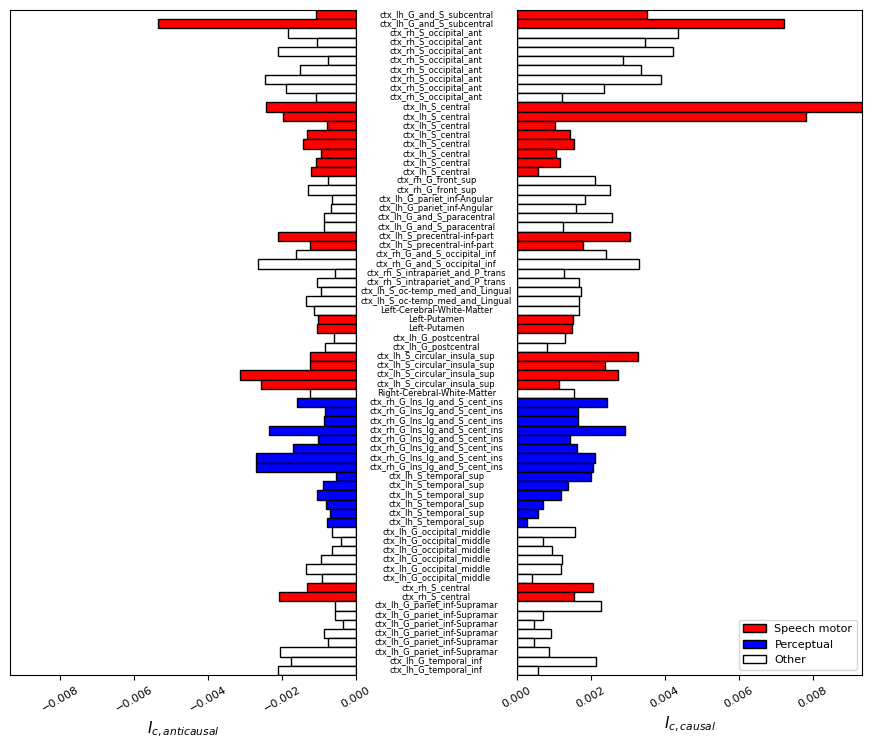

In [41]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.patches import Patch 
from collections import defaultdict

# --------------------------------------------
# Helper (you already defined something similar)
# --------------------------------------------
def extract_base_label(lbl):
    if "_ch" in lbl:
        base = lbl.split("_ch", 1)[1]
        base = base.split("_", 1)[1]
    else:
        base = lbl
    return base

# --------------------------------------------
# 1. Group by anatomical label
# --------------------------------------------
grouped = defaultdict(list)

for lbl, vals in electrode_avg.items():
    base = extract_base_label(lbl)
    grouped[base].append((lbl, vals))

# --------------------------------------------
# 2. Sort within each group
# --------------------------------------------
for base in grouped:
    grouped[base] = sorted(
        grouped[base],
        key=lambda x: (x[1]["IA"] - x[1]["IB"]),
        reverse=True
    )

# --------------------------------------------
# 3. Sort groups by mean dominance
# --------------------------------------------
group_order = sorted(
    grouped.keys(),
    key=lambda b: np.mean([v["IA"] - v["IB"] for _, v in grouped[b]]),
    reverse=True
)

# --------------------------------------------
# 4. Flatten
# --------------------------------------------
sorted_elec = []
for base in group_order:
    sorted_elec.extend(grouped[base])

# --------------------------------------------
# 5. Extract values
# --------------------------------------------
labels = [x[0] for x in sorted_elec]
IA_vals = np.array([x[1]["IA"] for x in sorted_elec])
IB_vals = np.array([x[1]["IB"] for x in sorted_elec])


# # -------------------------------------------------
# # Filter out channels with zero on BOTH sides
# # -------------------------------------------------
eps = 1e-10
mask = ~((np.abs(IA_vals) < eps) & (np.abs(IB_vals) < eps))

labels = [lbl for lbl, m in zip(labels, mask) if m]
IA_vals = IA_vals[mask]
IB_vals = IB_vals[mask]
# # --------------------------------------------------

# Use integer y positions with no gaps
y_pos = np.arange(len(labels))

# -------------------------------------------------
# Color mapping
# -------------------------------------------------
color_map = {
    1: "red",     # motor
    0: "white",   # undefined
    -1: "blue"    # sensory
}

def extract_base_label(lbl):
    # If it's a unique channel key → extract original label
    if "_ch" in lbl:
        return lbl.split("_ch")[-1].split("_", 1)[-1]
    return lbl  # white matter stays unchanged

colors = [
    color_map[label_to_class.get(extract_base_label(lbl), 0)]
    for lbl in labels
]

# Split values
pos_vals = IA_vals     # causal → right
neg_vals = -IB_vals    # anti-causal → left (negative direction)

# -------------------------------------------------
# Figure layout
# -------------------------------------------------
fig = plt.figure(figsize=(11, max(6, 0.12 * len(labels))))

gs = fig.add_gridspec(
    1, 3,
    width_ratios=[1, 0.45, 1],   # ← narrower label column
    wspace=0.01                # ← tighter spacing
)

ax_left  = fig.add_subplot(gs[0, 0])
ax_mid   = fig.add_subplot(gs[0, 1])
ax_right = fig.add_subplot(gs[0, 2])

bar_height = 1   # bars TOUCH

# -------------------------------------------------
# Left axis (negative values)
# -------------------------------------------------
ax_left.barh(
    y_pos,
    width=IB_vals,          # positive width
    left=-IB_vals,          # shift left
    color=colors,
    edgecolor="black",
    height=bar_height
)

ax_left.set_ylim(-0.5, len(labels) - 0.5)
ax_left.invert_yaxis()
ax_left.set_yticks([])

for tick in ax_left.get_xticklabels():
    tick.set_rotation(30)
    tick.set_fontsize(8)

### Right axis (positive values)
# -------------------------------------------------
ax_right.barh(
    y_pos,
    IA_vals,
    color=colors,
    edgecolor="black",
    height=bar_height
)

ax_right.set_ylim(-0.5, len(labels) - 0.5)
ax_right.invert_yaxis()
ax_right.set_yticks([])

for tick in ax_right.get_xticklabels():
    tick.set_rotation(30)
    tick.set_fontsize(8)

## Middle axis (labels)
# -------------------------------------------------
ax_mid.set_ylim(-0.5, len(labels) - 0.5)
ax_mid.invert_yaxis()
ax_mid.axis("off")

ax_left.set_xlabel("$I_{c,anticausal}$", fontsize=11)
ax_right.set_xlabel("$I_{c,causal}$", fontsize=11)

## add symmetry to plots
max_val = max(np.max(IA_vals), np.max(IB_vals))

ax_left.set_xlim(-max_val, 0)
ax_right.set_xlim(0, max_val)

def shorten_label(lbl):
    base = extract_base_label(lbl)
    return base

for y, lbl in zip(y_pos, labels):
    display_lbl = shorten_label(lbl)
    ax_mid.text(
        0.5, y,
        display_lbl,
        ha="center",
        va="center",
        fontsize=6   # tighter label spacing
    )

### Legend
legend_elements = [
    Patch(facecolor="red", edgecolor="black", label="Speech motor"),
    Patch(facecolor="blue", edgecolor="black", label="Perceptual"),
    Patch(facecolor="white", edgecolor="black", label="Other")
]

ax_right.legend(
    handles=legend_elements,
    loc="lower right",
    frameon=True,
    fontsize=8
)

plt.tight_layout()
# plt.savefig('/home/ahmed348/TCNN_repo/figures/causality_predicts_motor_or_sensory.pdf', bbox_inches='tight', dpi=600)
# # plt.savefig('/home/ahmed348/TCNN_repo/figures/non_motor_speech_production_as_0.pdf', bbox_inches='tight', dpi=600)
plt.savefig(f'/home/ahmed348/TCNN_repo/figures_extra/sub_{sub_list[0]}.pdf', bbox_inches='tight', dpi=600)
# tpl_save(
#     figure=fig,
#     filepath="/home/ahmed348/TCNN_repo/tex_files/causality_predicts_motor_or_sensory.tex"
# )